In [1]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

Using cupy


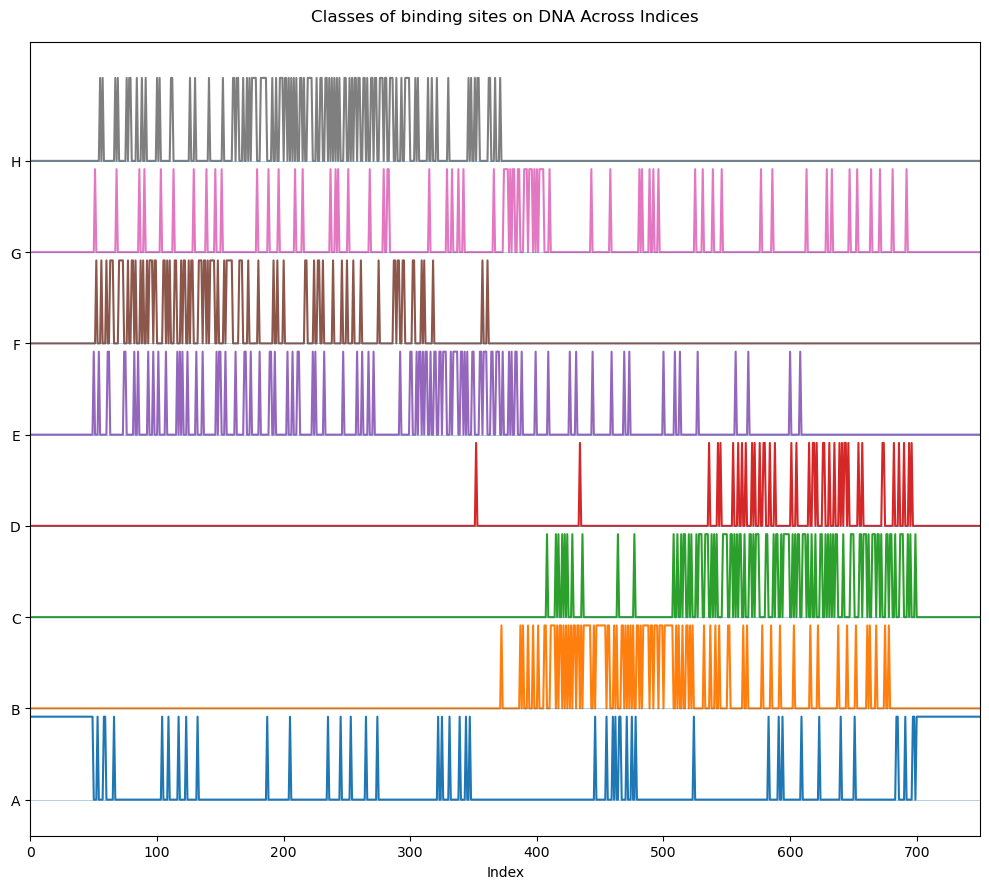

In [2]:
ns = 750
chain_interaction_binary = IMR90_data(ns, split_class_zero=False)

In [3]:
from joblib import Parallel, delayed
from itertools import product

'''
def parameter_sweep(num):
    ChiNs = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

    results = Parallel(n_jobs = 2, backend="threading")(
        delayed(single_run)(N)
        for N in N
    )

    phi_blocks_results, qsr_results = zip(*results)
    return phi_blocks_results, qsr_results
'''

def single_run(Chi_N_pp, Chi_N_ps):

    chi_pp = Chi_N_pp*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
    chi_ps = Chi_N_ps*xp.ones(chain_interaction_binary.shape[0])

    N = 1000

    nx = ny = 128
    initial_qsr = xp.ones((nx, ny))
    L = 56 #dimension of the box

    boundary = xp.random.rand(nx,ny)

    polymer = Scft(
        N = N,
        Lx=L, Ly=L,
        phibar=0.1, # volume fraction of polymer
        l_p=xp.sqrt(N),
        n_seg=1, # contour length of polymer normalized from 0-1
        nx=nx, ny=ny,
        ns=ns,
        iterations=8000,
        error_tol=1e-12,
        chain_interaction=xp.asarray(chain_interaction_binary),
        self_avoiding=0,
        initial_qsr=xp.array(boundary),
        mixing_rate=0.005,
        chi_polymer_block = chi_pp,
        chi_polymer_s = chi_ps,
        PB = 1,
        close_boundary=True,
    )

    wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)
    wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist)

    corr_2d = pair_correlation_2D_vectorized_numba(to_numpy(qsr*qsr_d))

    return to_numpy(phi_blocks), to_numpy(qsr), diff, corr_2d, free_energy_hist

def parameter_sweep_2d(n_jobs=3, backend="loky", seed=5):

    ChiNpp = np.array([800, 850, 900, 950, 1000])
    ChiNps = np.array([800, 850, 900, 950, 1000])

    combos = list(product(ChiNpp, ChiNps))  # order: outer over Ns, inner over phibars

    results = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(single_run)(ChiNpp, ChiNps) for (ChiNpp, ChiNps) in
        tqdm(combos, total = len(combos))
    )
    phi_list, qsr_list, diff_list, corr_2d_list, free_energy_hist = zip(*results)

    M, K = len(ChiNpp), len(ChiNps)
    phi_blocks_grid = np.empty((M, K), dtype=object)
    qsr_grid        = np.empty((M, K), dtype=object)
    diff_grid       = np.empty((M, K), dtype=object)
    corr_2d_grid    = np.empty((M, K), dtype=object)
    free_energy_grid = np.empty((M, K), dtype=object)

    # Fill grids in the same order as product(Ns, phibars)
    idx = 0
    for i in range(M):
        for j in range(K):
            phi_blocks_grid[i, j] = phi_list[idx]
            qsr_grid[i, j] = qsr_list[idx]
            diff_grid[i, j] = diff_list[idx]
            corr_2d_grid[i, j] = corr_2d_list[idx]
            free_energy_grid[i, j] = free_energy_hist[idx]
            idx += 1

    return ChiNpp.tolist(), ChiNps.tolist(), phi_blocks_grid, qsr_grid, diff_grid, corr_2d_grid, free_energy_grid


In [4]:
Ns, phibars, phi_blocks_grid, qsr_grid, diff_grid, corr_2d_grid, free_energy_grid = parameter_sweep_2d()
np.save("phi_blocks_grid", phi_blocks_grid)
np.save("qsr_grid", qsr_grid)
np.save("diff_grid", diff_grid)
np.save("corr_2d_grid", corr_2d_grid)
np.save("free_energy_grid", free_energy_grid)

  0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [8]:
phi_blocks_grid = np.array(phi_blocks_grid)
print(phi_blocks_grid.shape)
print(phi_blocks_grid[0,0].shape)

free_energy_grid = np.array(free_energy_grid)
print(free_energy_grid.shape)

(5, 5)
(9, 128, 128)
(5, 5)


PP = 1000,  PS = 600


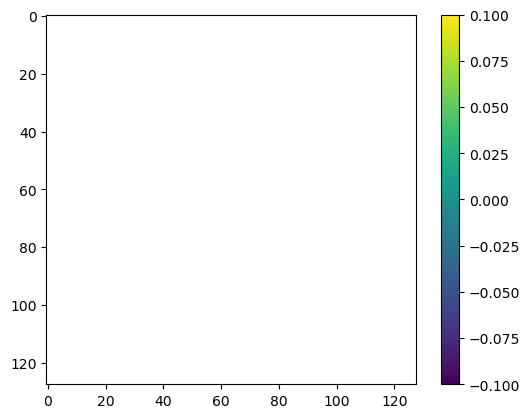

In [7]:
m = 0
n = 2
print(f"PP = {int(Ns[m])},  PS = {phibars[n]:g}")
phi = np.sum(phi_blocks_grid[m,n], axis=0)
plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

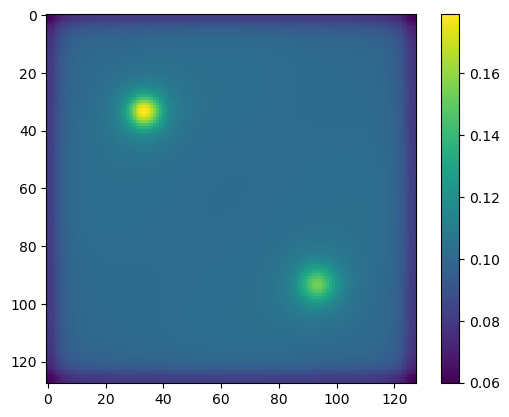

In [13]:
phi = np.sum(phi_blocks_grid[-1,0], axis=0)
plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

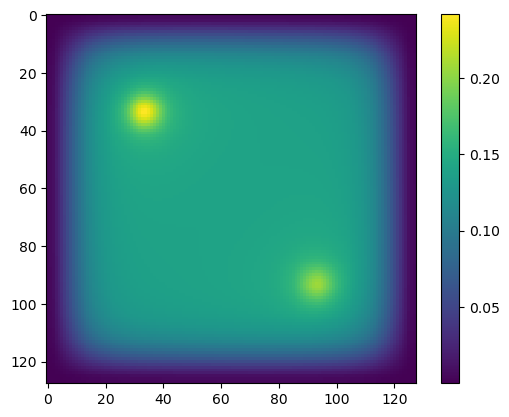

In [14]:
phi = np.sum(phi_blocks_grid[0,-1], axis=0)
plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

L = 30
def plot_sweep_2d(phi_blocks_grid, Ns, phibars, Lx=L, Ly=L,
                  percentile=92, shift_x=0, shift_y=0, dpi=200):
    """
    phi_blocks_grid: object array with shape (len(Ns), len(phibars))
                     where [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    Ns = list(Ns)
    phibars = list(phibars)

    #if save_dir:
        #Path(save_dir).mkdir(parents=True, exist_ok=True)

    M, K = phi_blocks_grid.shape
    for i in range(M):
        for j in range(K):
            phi_blocks = phi_blocks_grid[i, j]

            # Clear any prior figures so we always work on the one just created
            plt.close('all')

            # Draw (this likely creates a new fig internally)
            plot_phi_blocks_periodic(
                np.flip(phi_blocks, axis=0),
                extent=(0, Lx, 0, Ly),
                percentile=percentile,
                shift_x=shift_x,
                shift_y=shift_y,
            )

            print(f"PP = {int(Ns[i])},  PS = {phibars[j]:g}")

            plt.show()



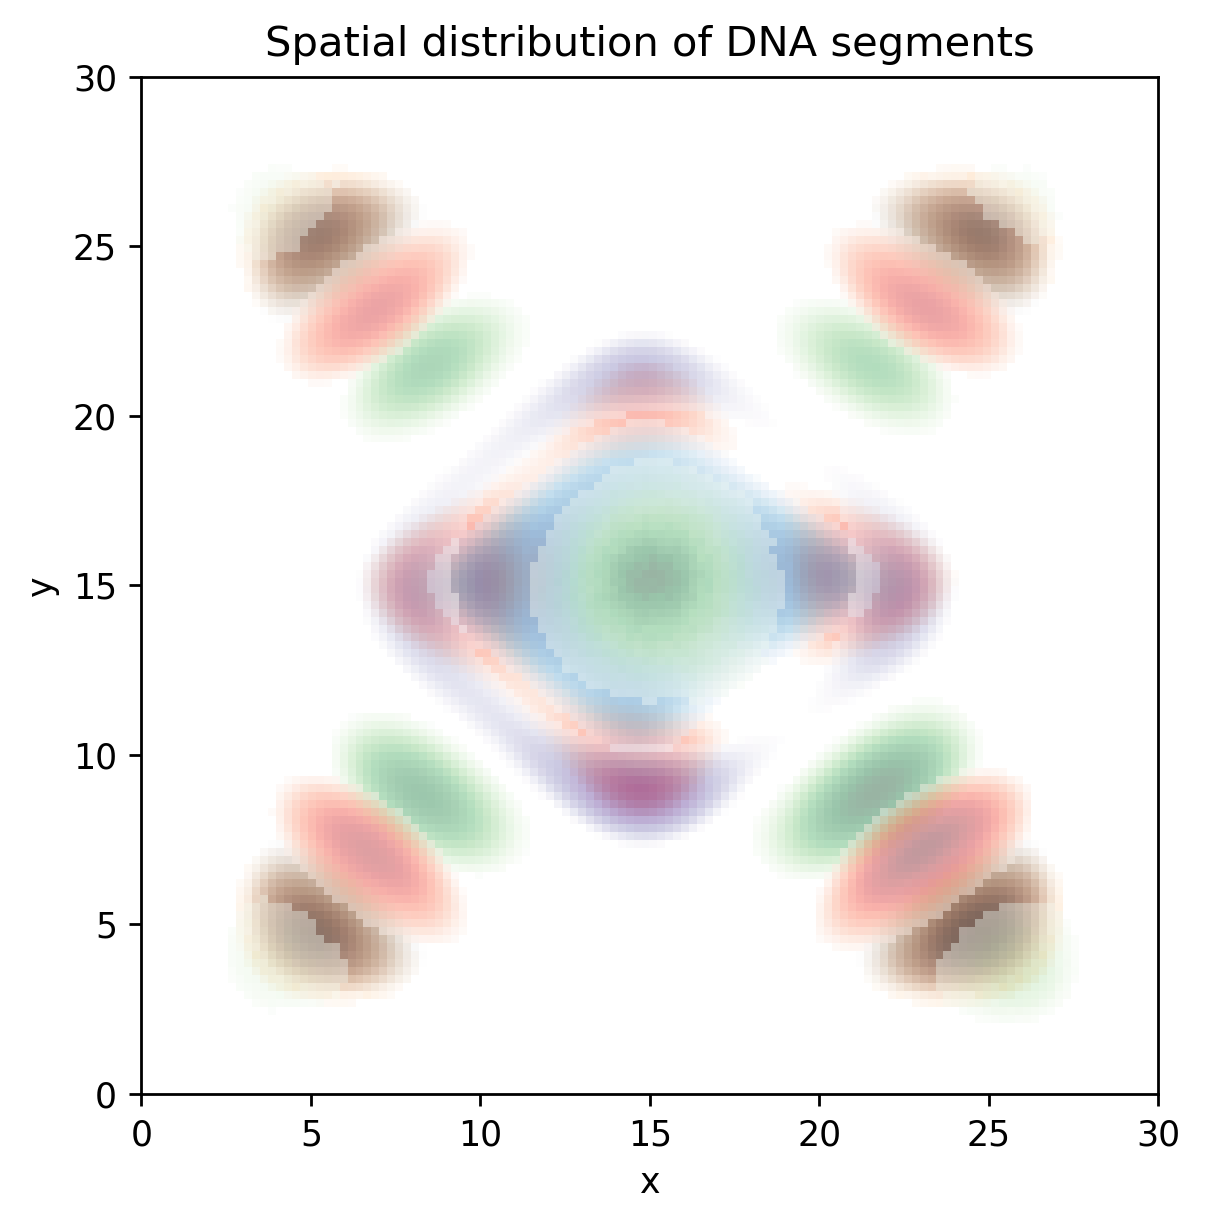

PP = 800,  PS = 800


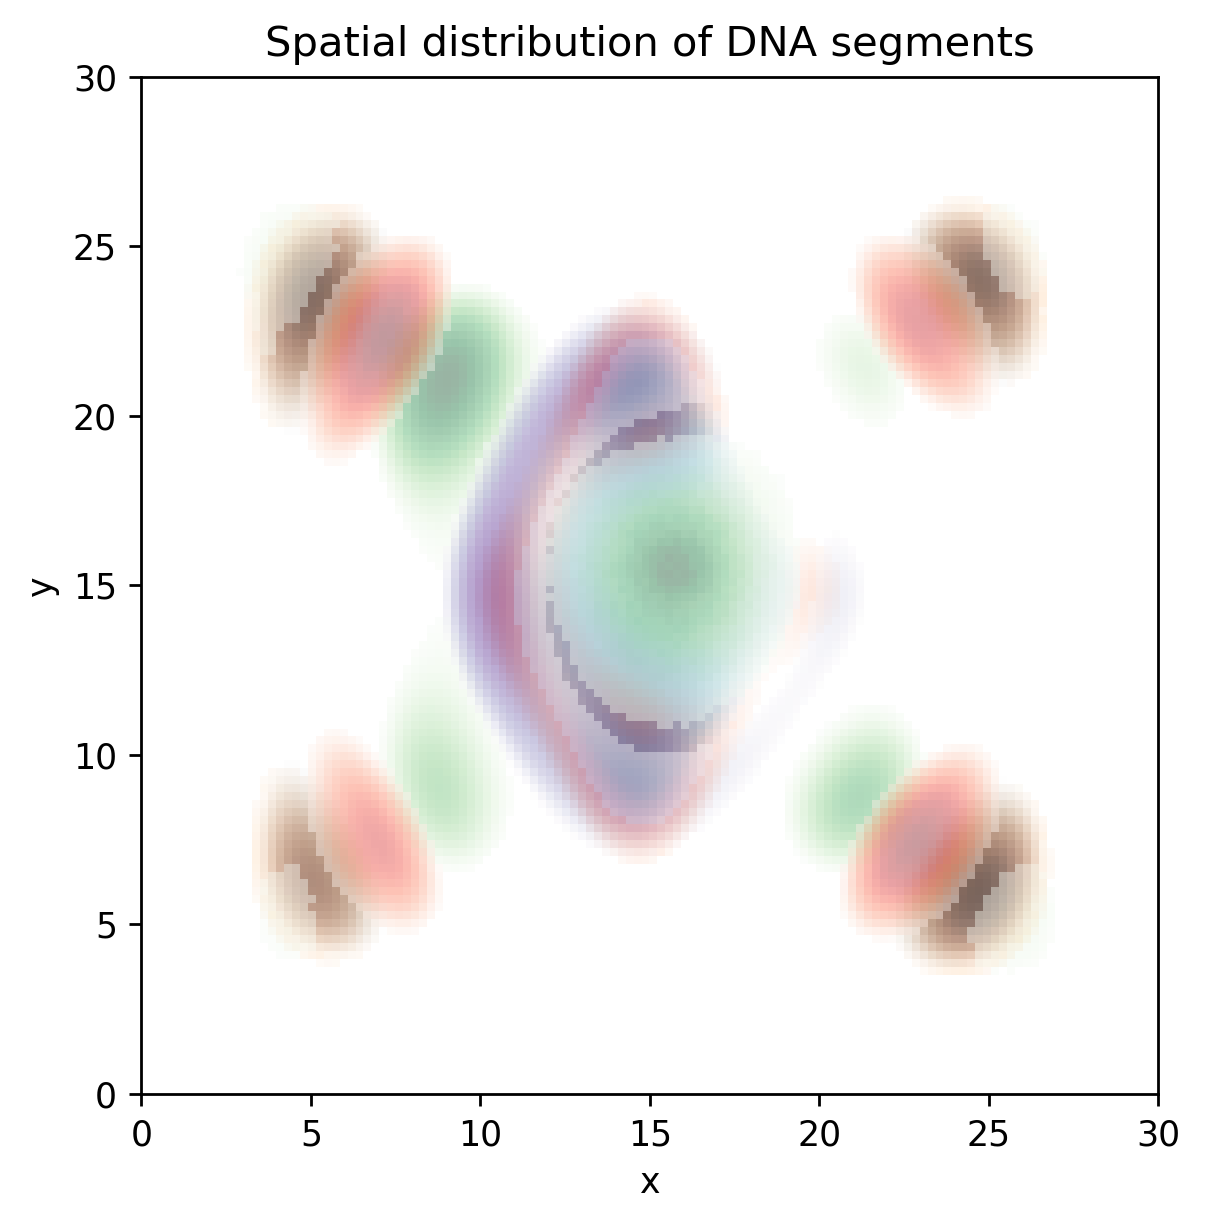

PP = 800,  PS = 850


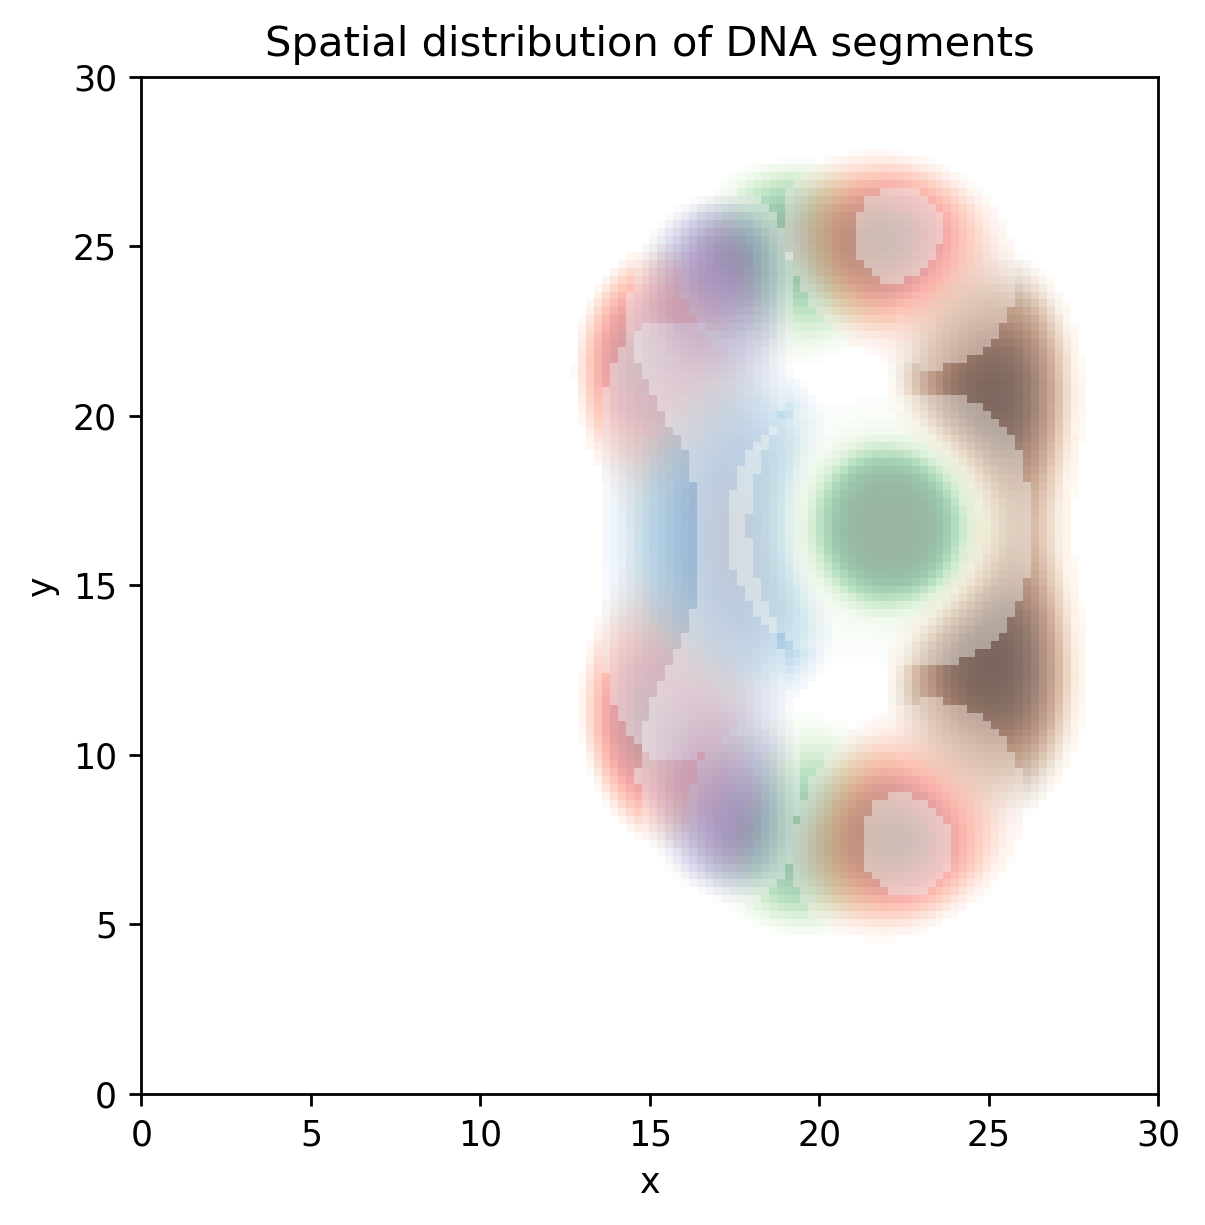

PP = 800,  PS = 900


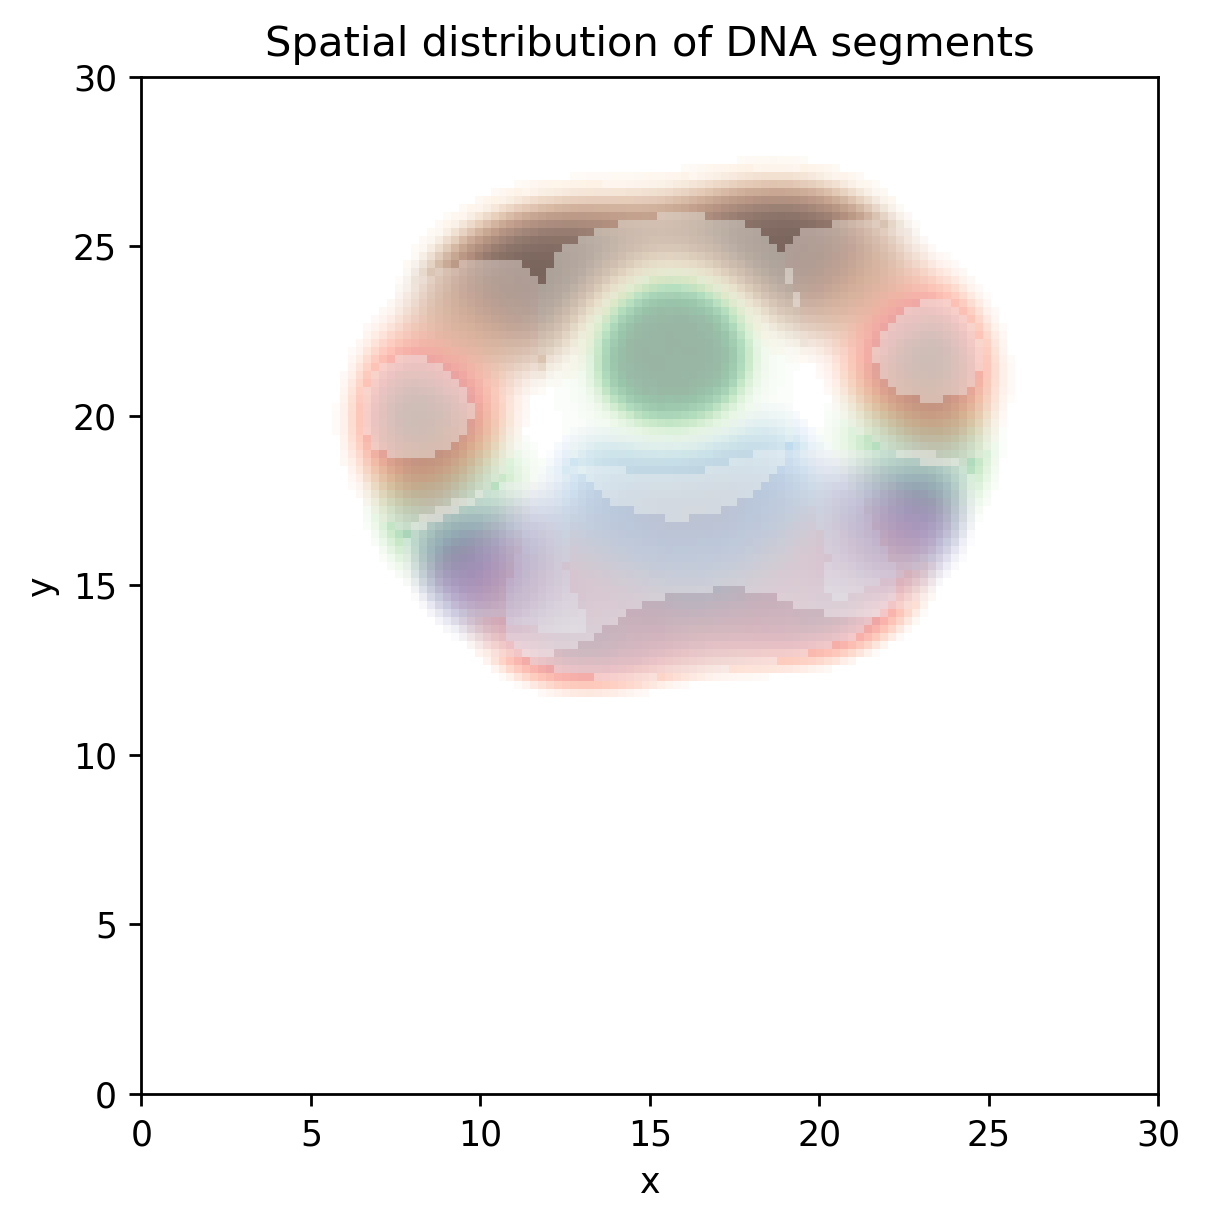

PP = 800,  PS = 950


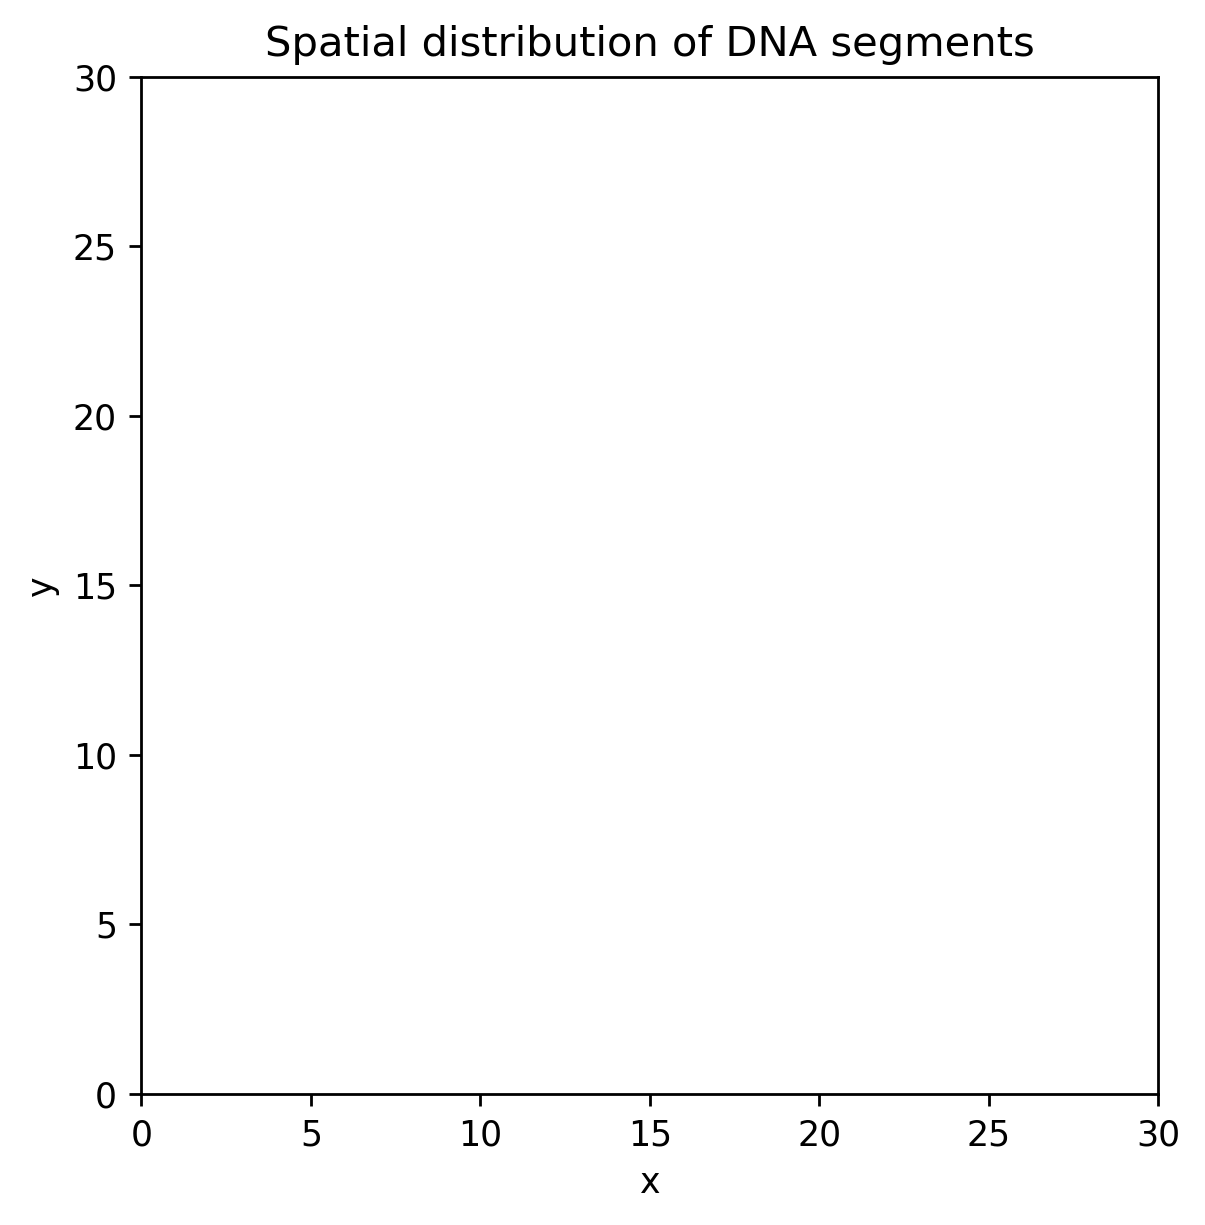

PP = 800,  PS = 1000


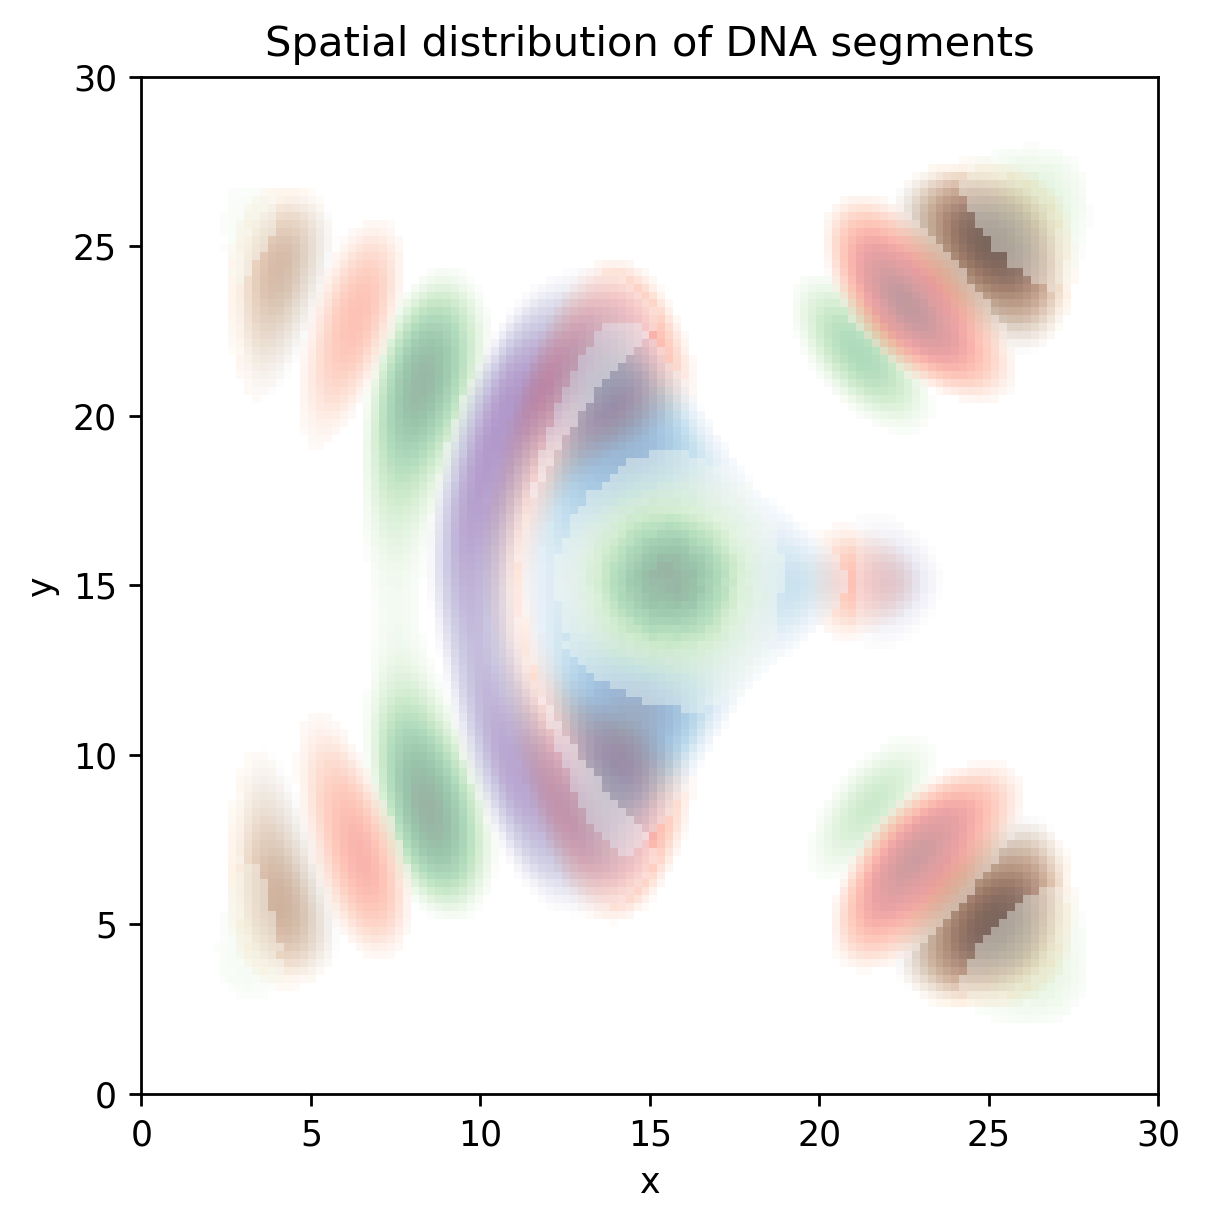

PP = 850,  PS = 800


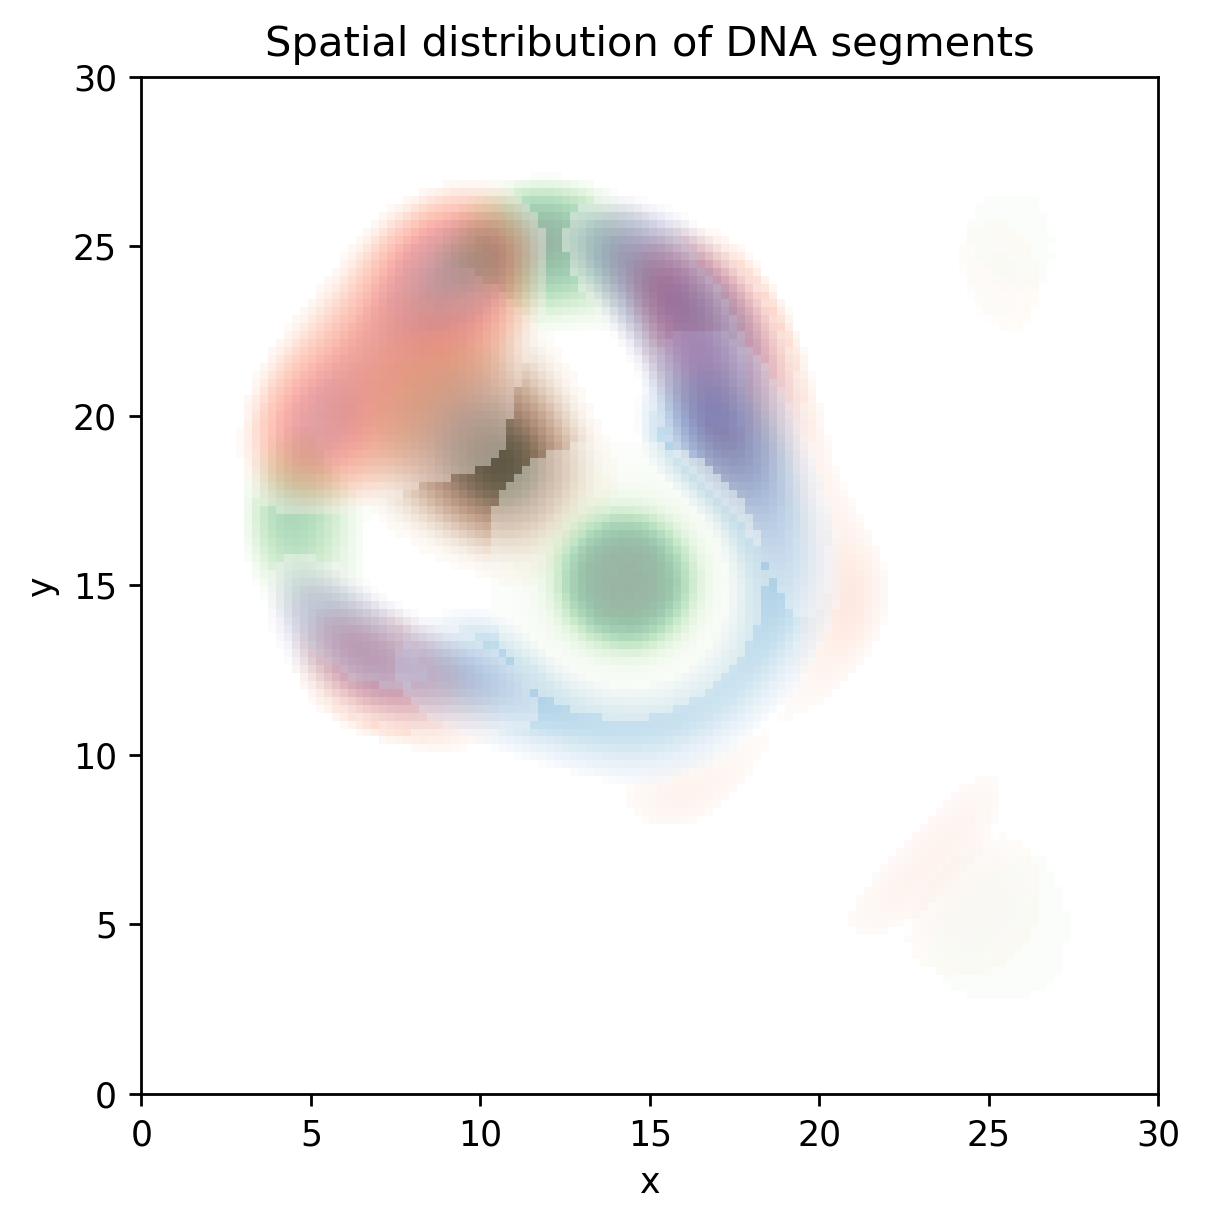

PP = 850,  PS = 850


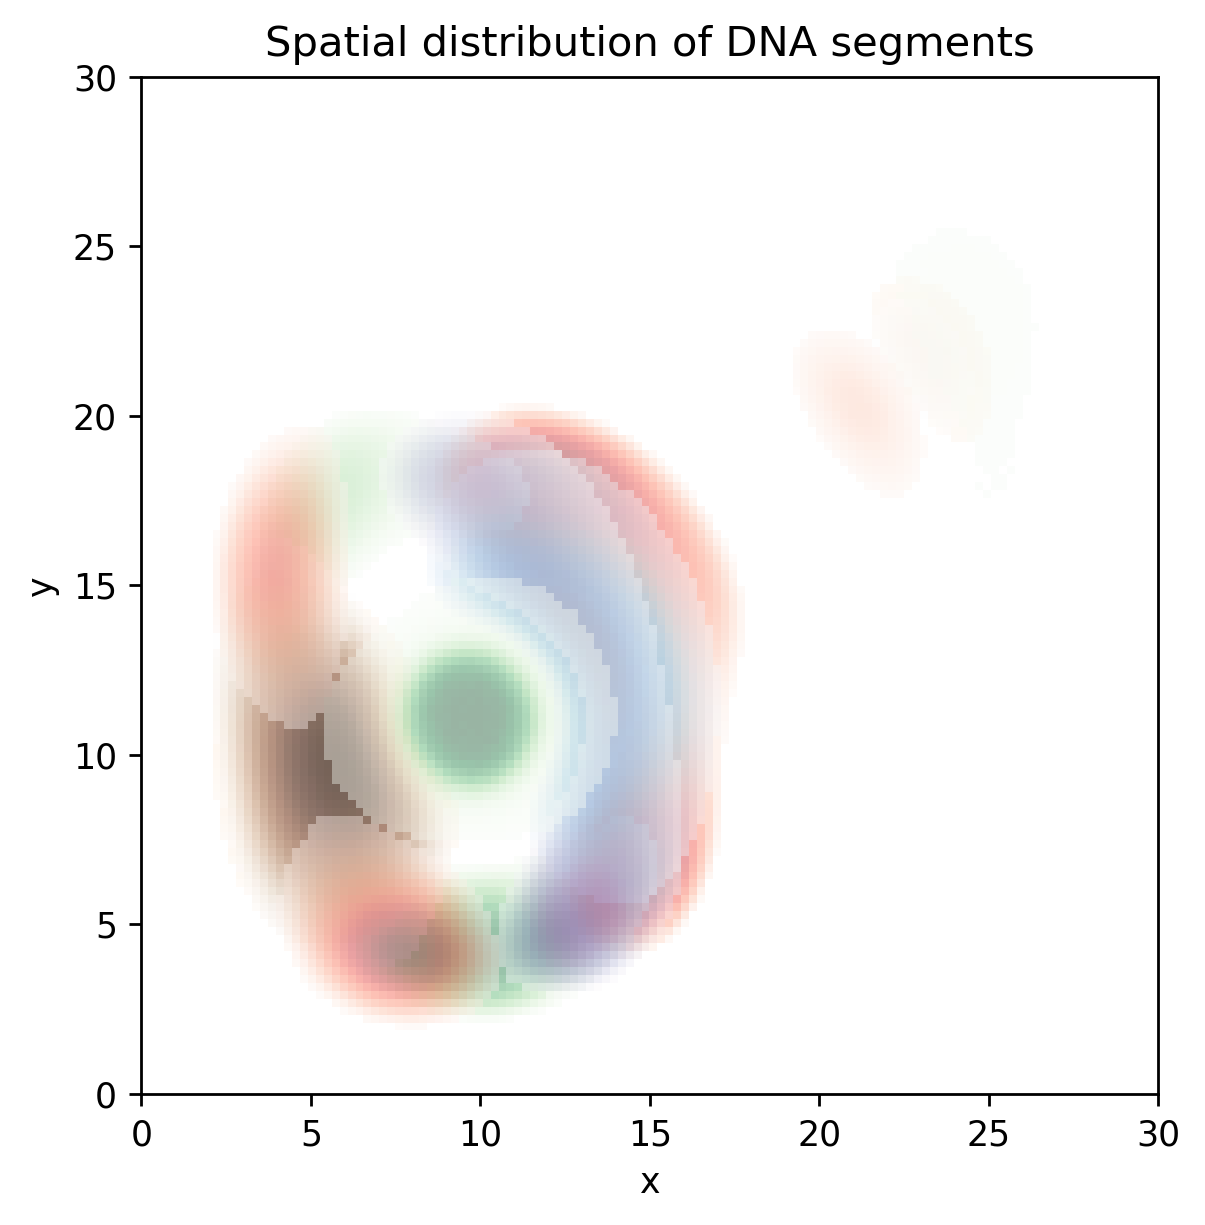

PP = 850,  PS = 900


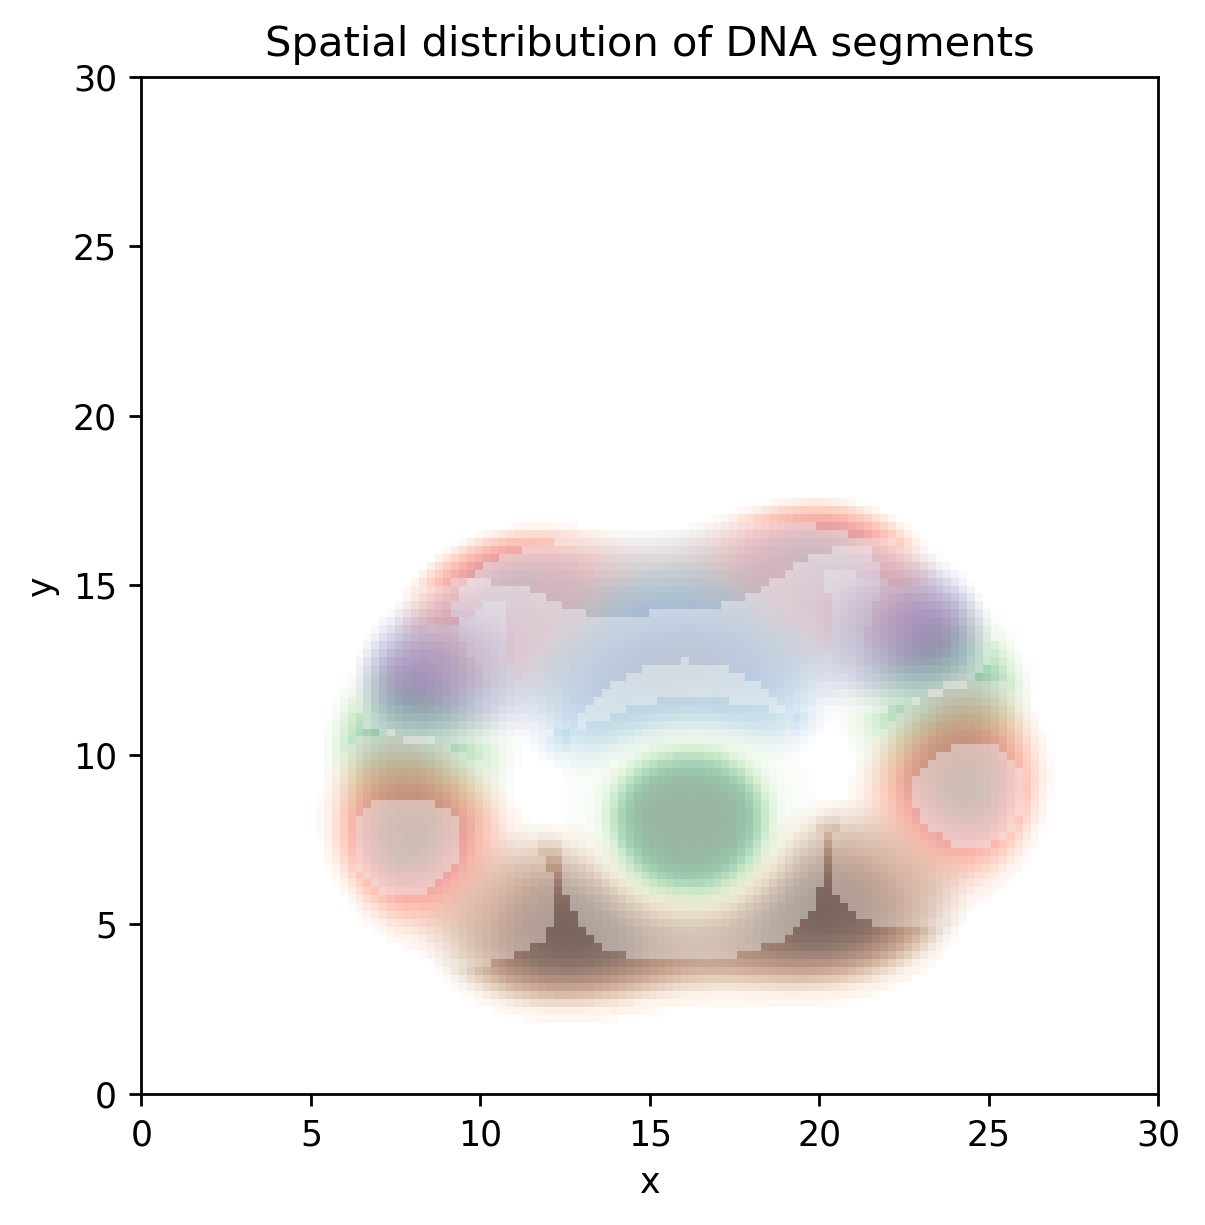

PP = 850,  PS = 950


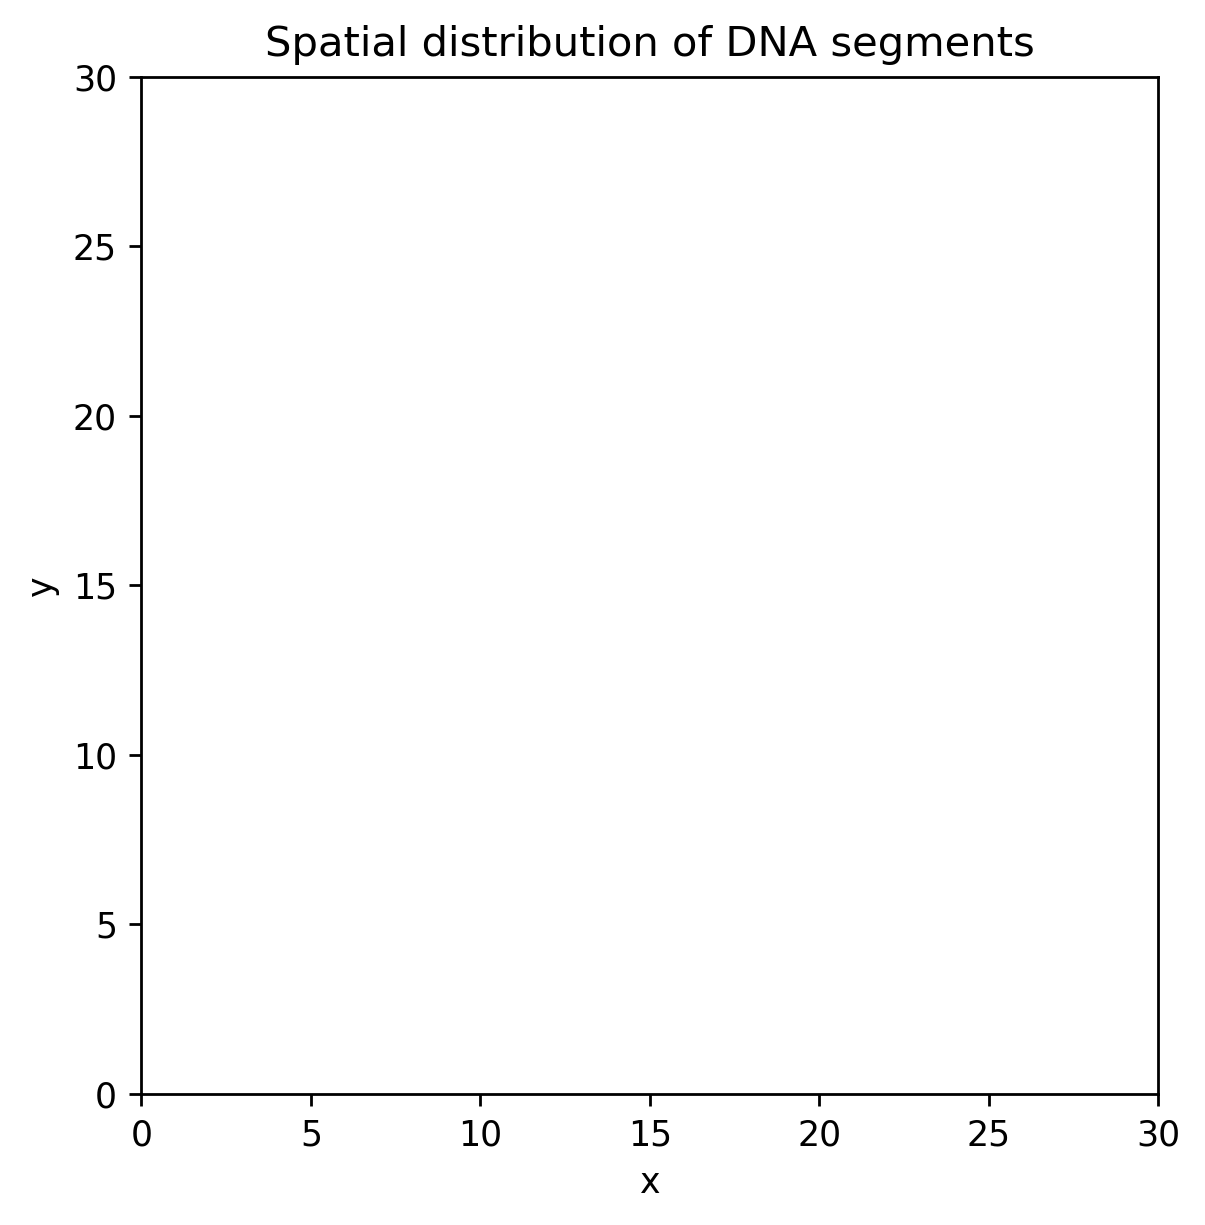

PP = 850,  PS = 1000


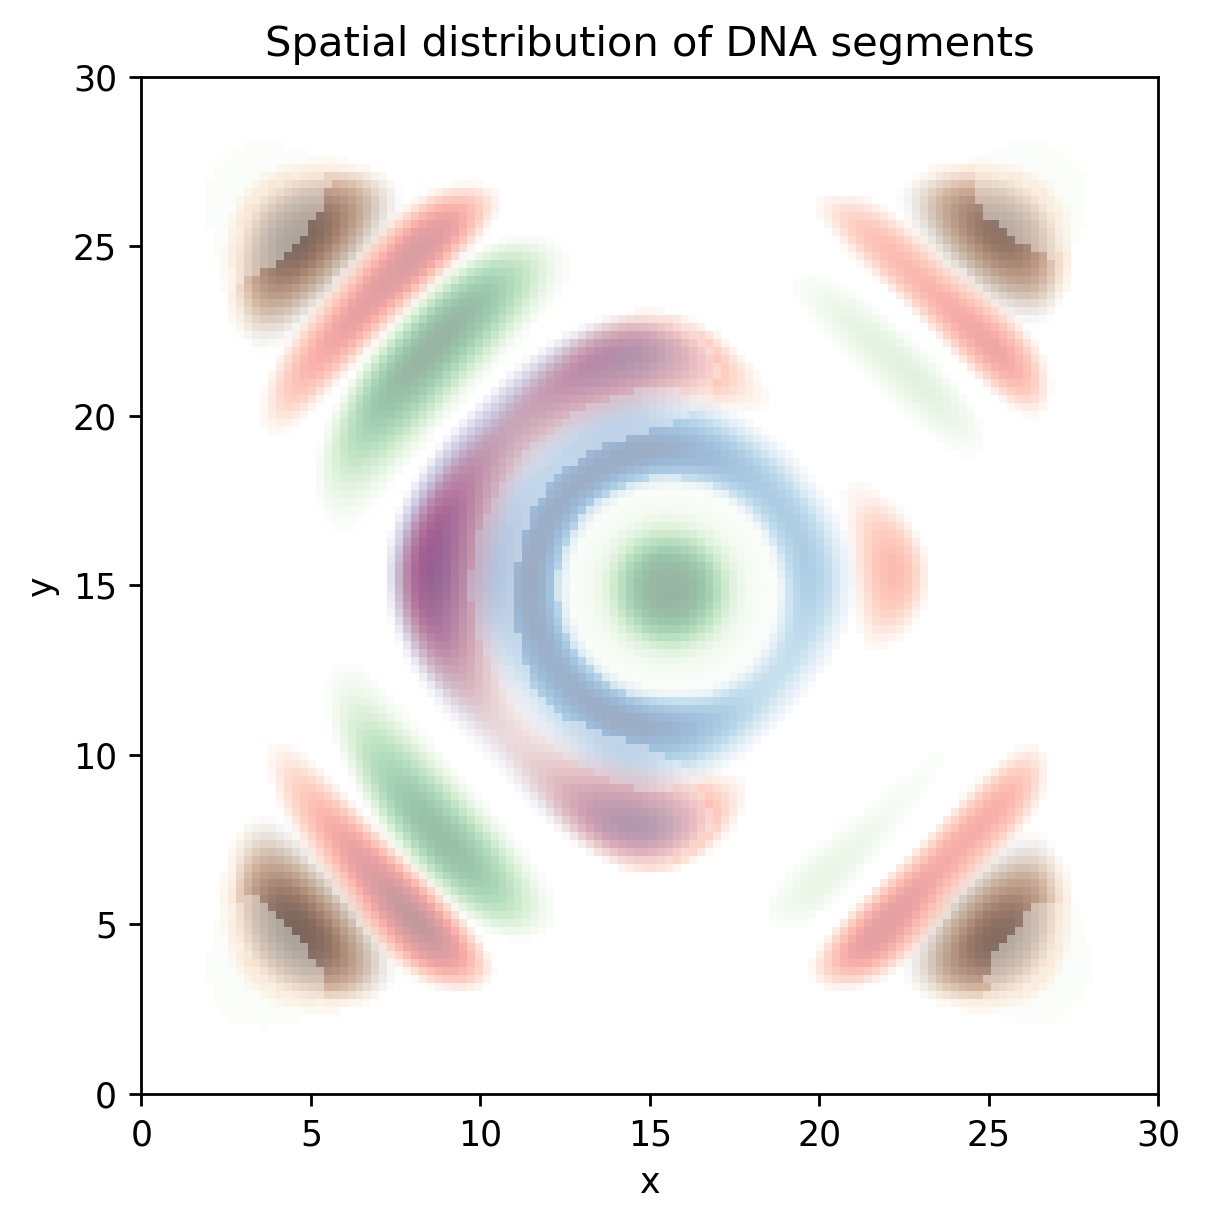

PP = 900,  PS = 800


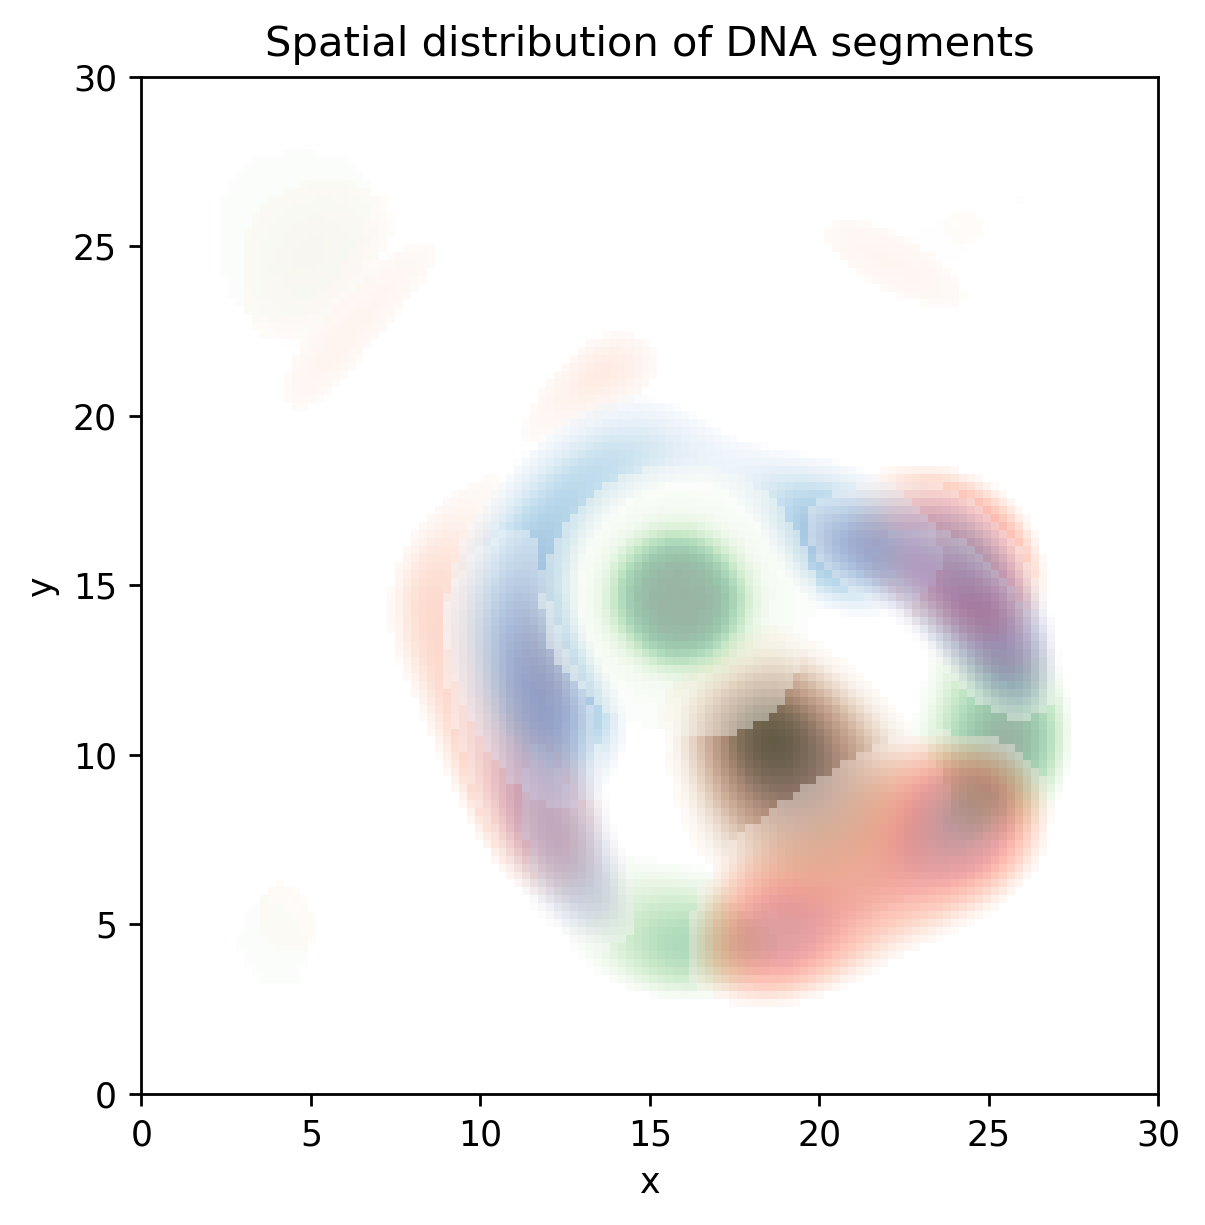

PP = 900,  PS = 850


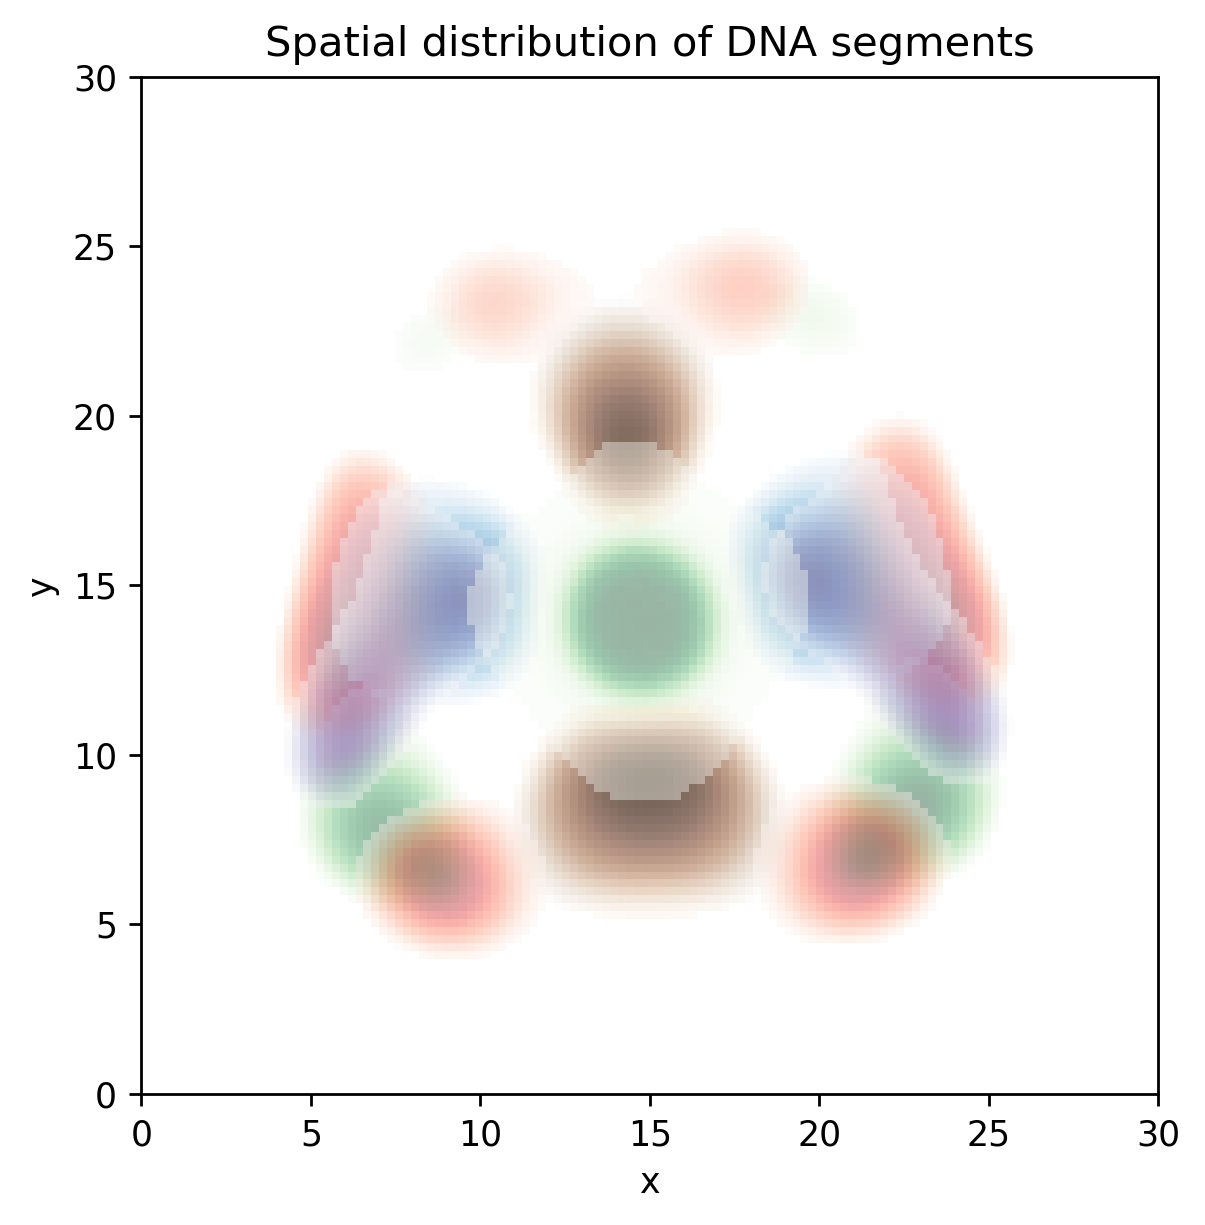

PP = 900,  PS = 900


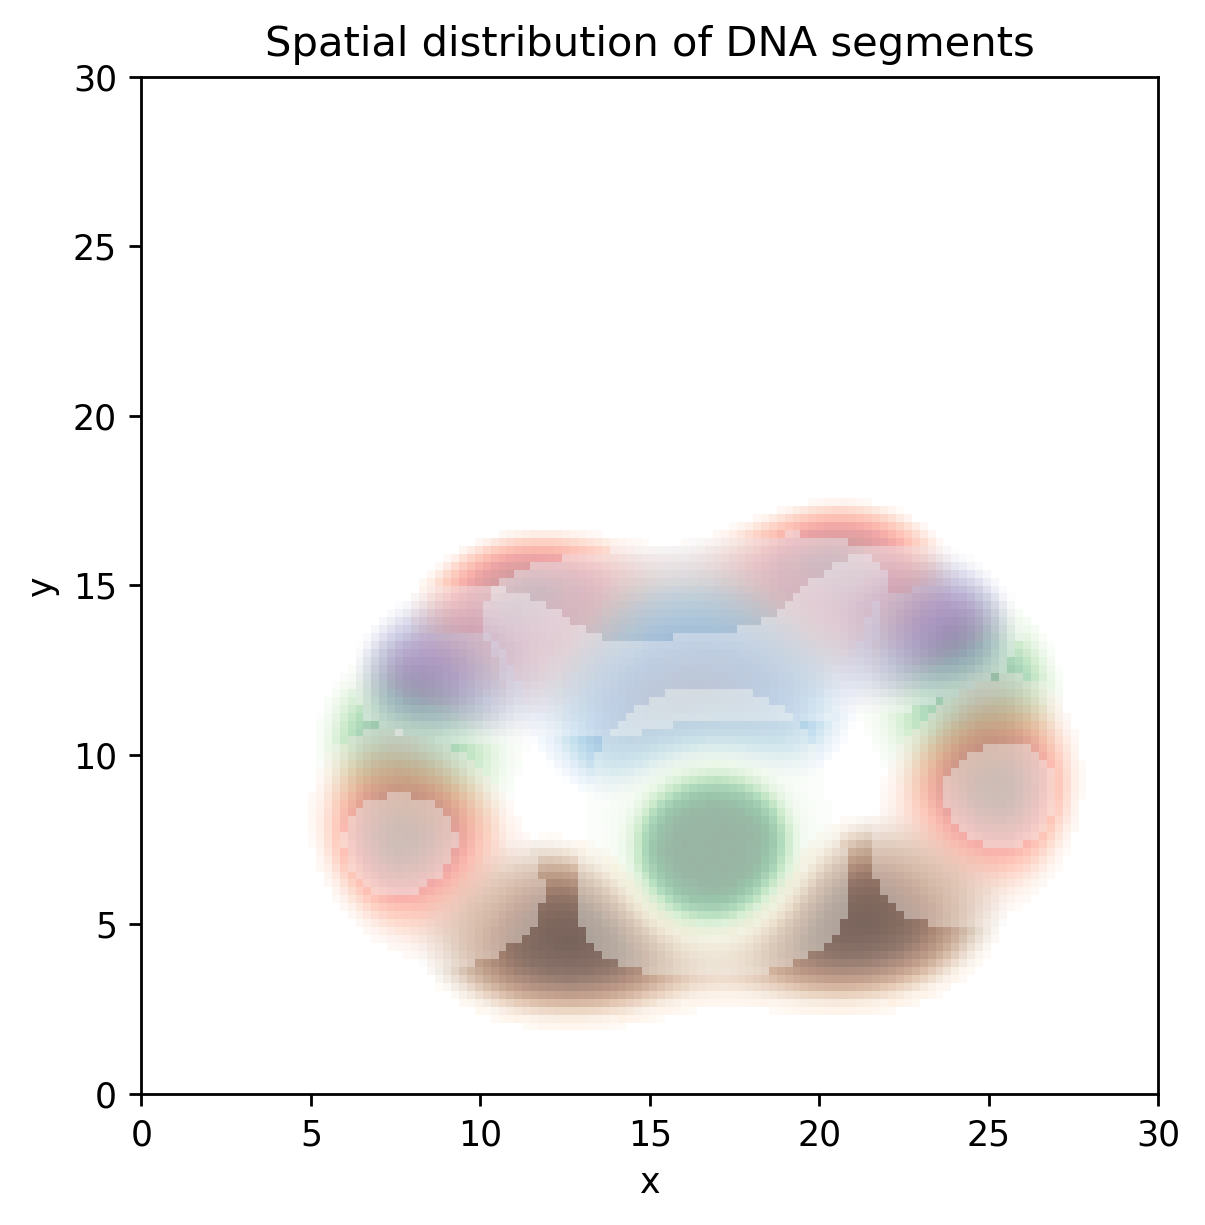

PP = 900,  PS = 950


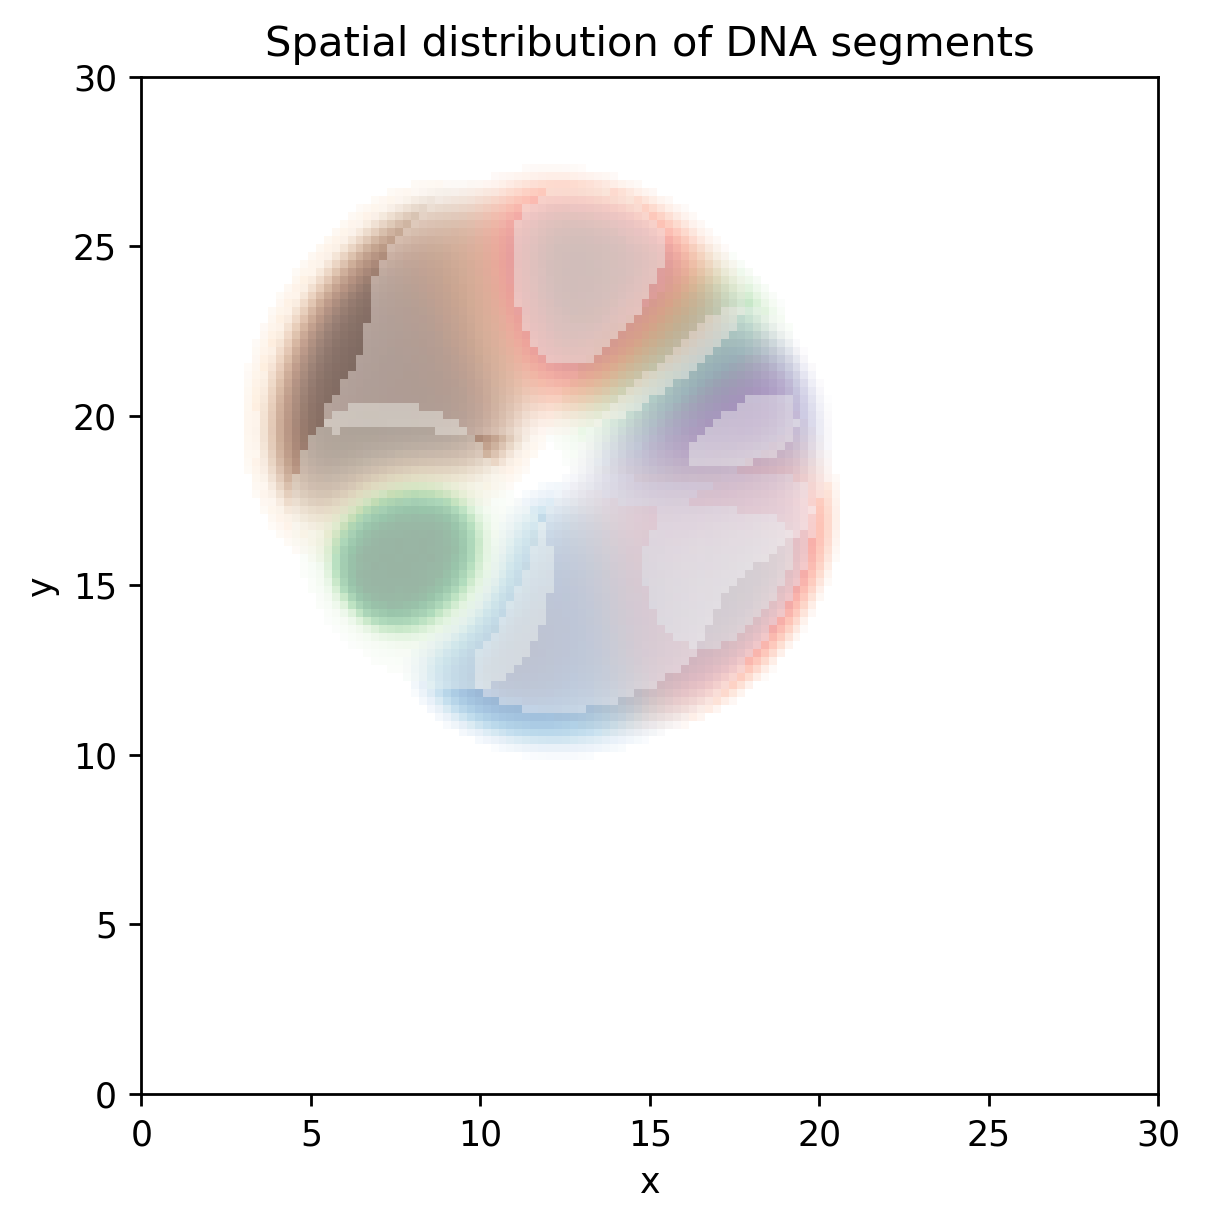

PP = 900,  PS = 1000


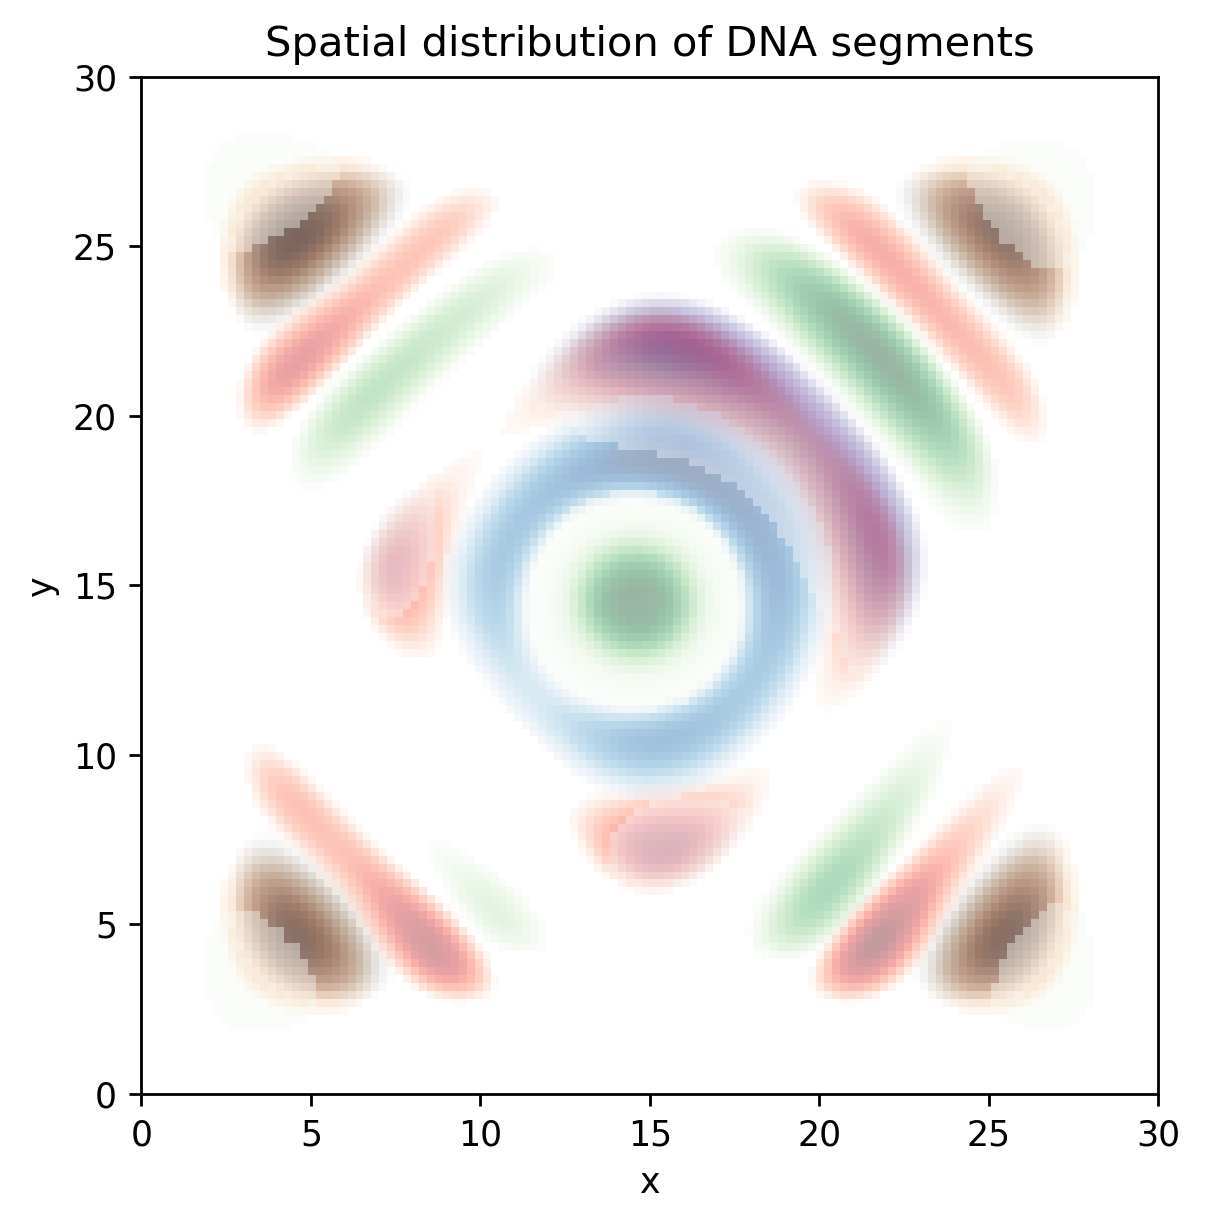

PP = 950,  PS = 800


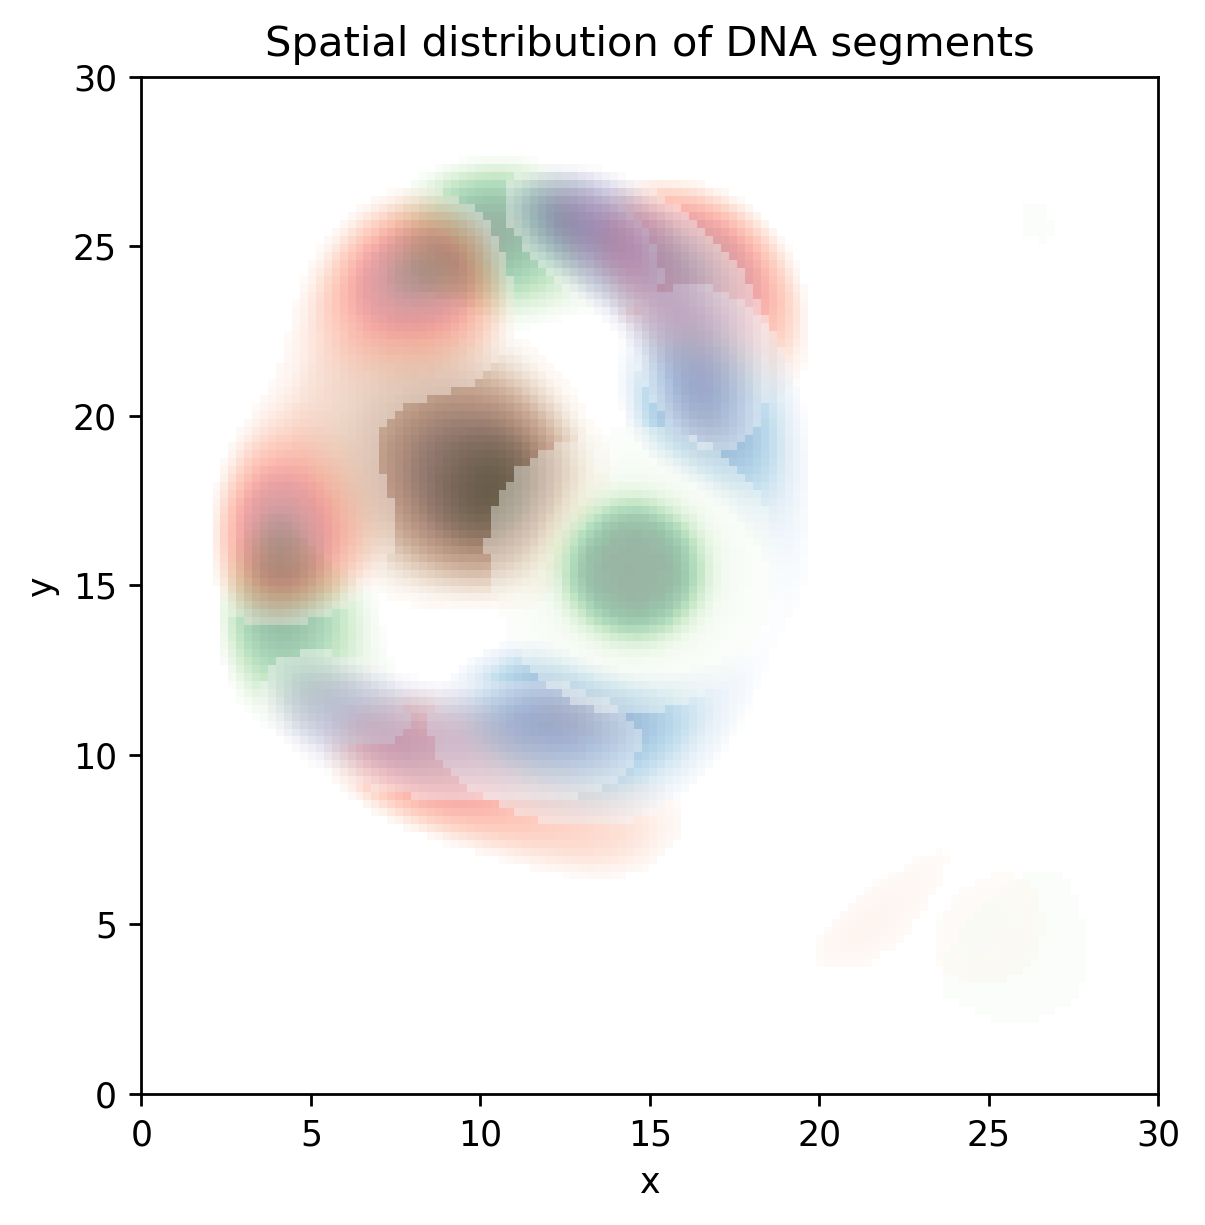

PP = 950,  PS = 850


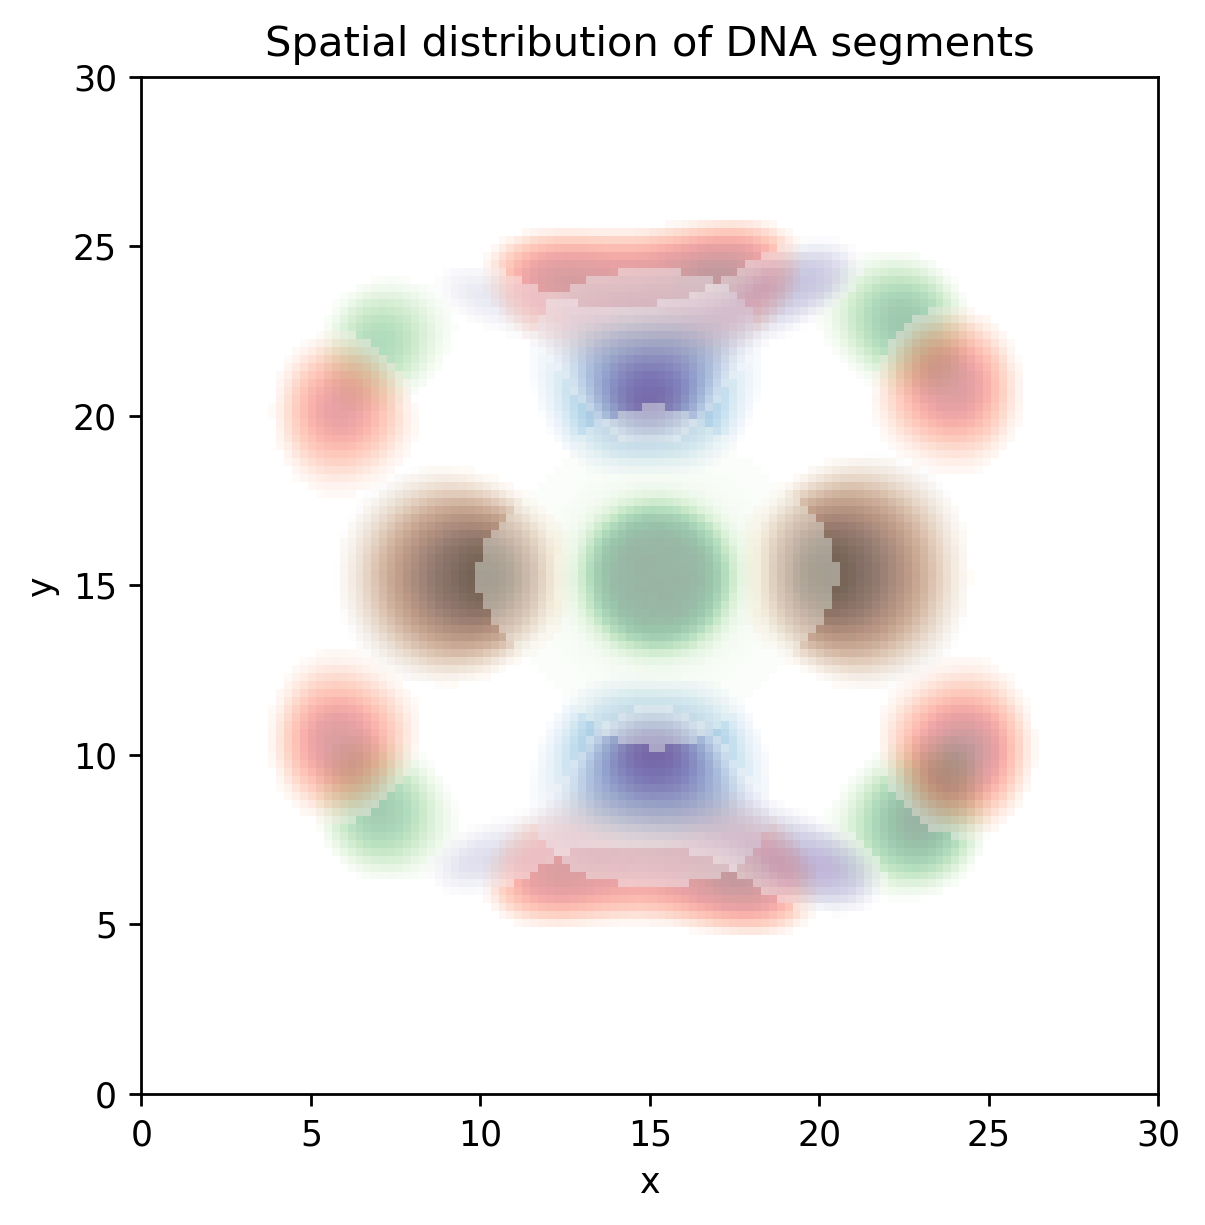

PP = 950,  PS = 900


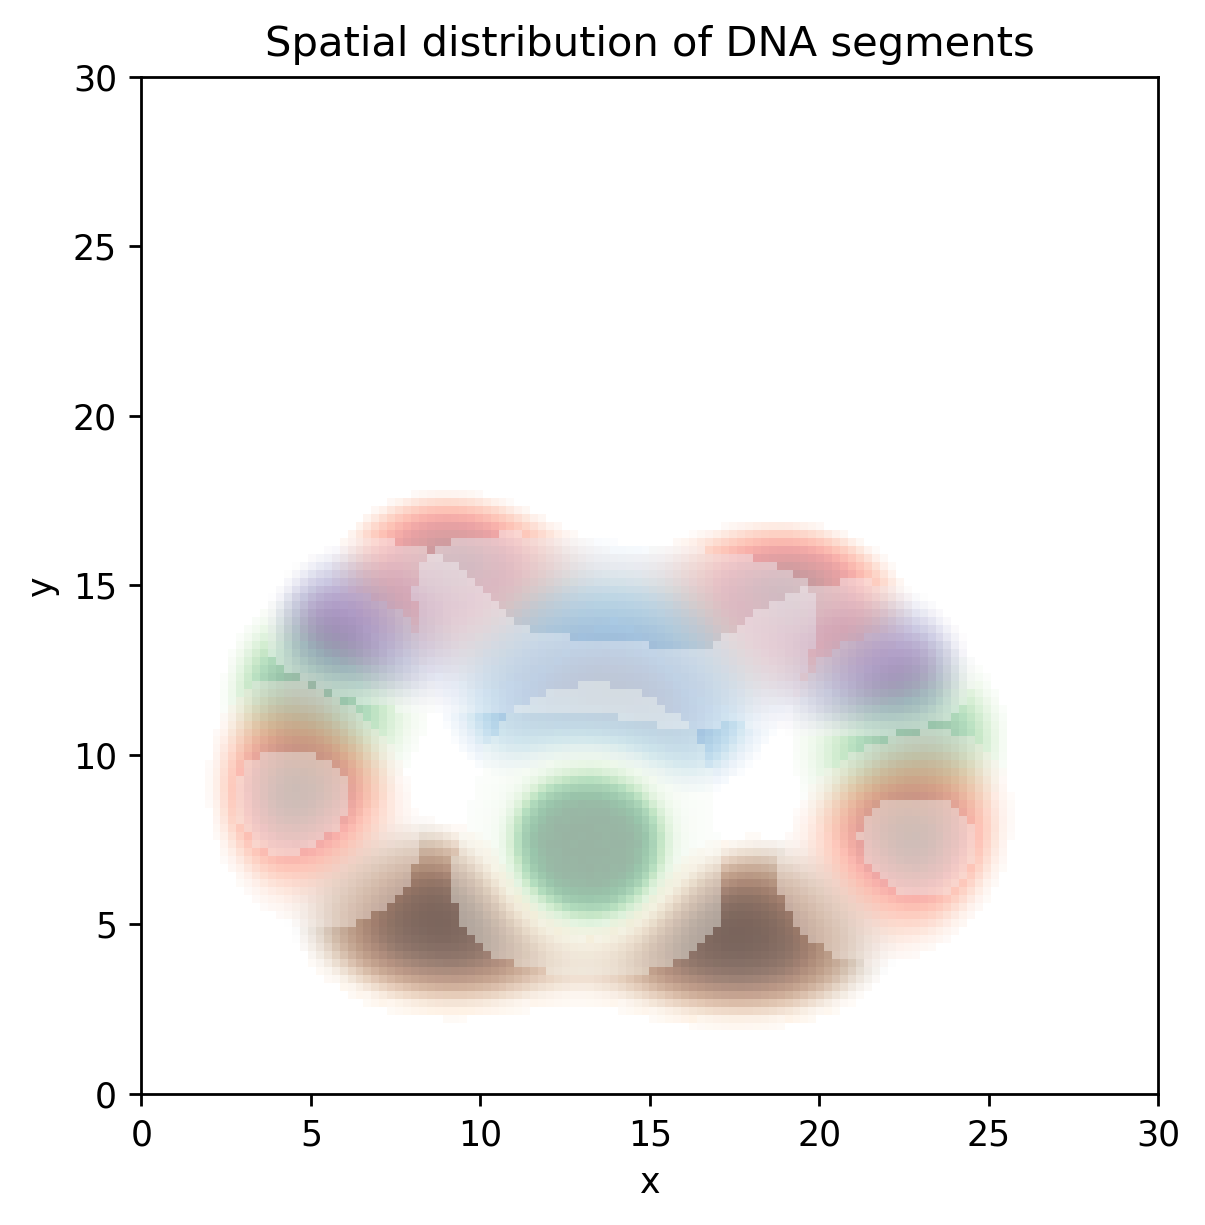

PP = 950,  PS = 950


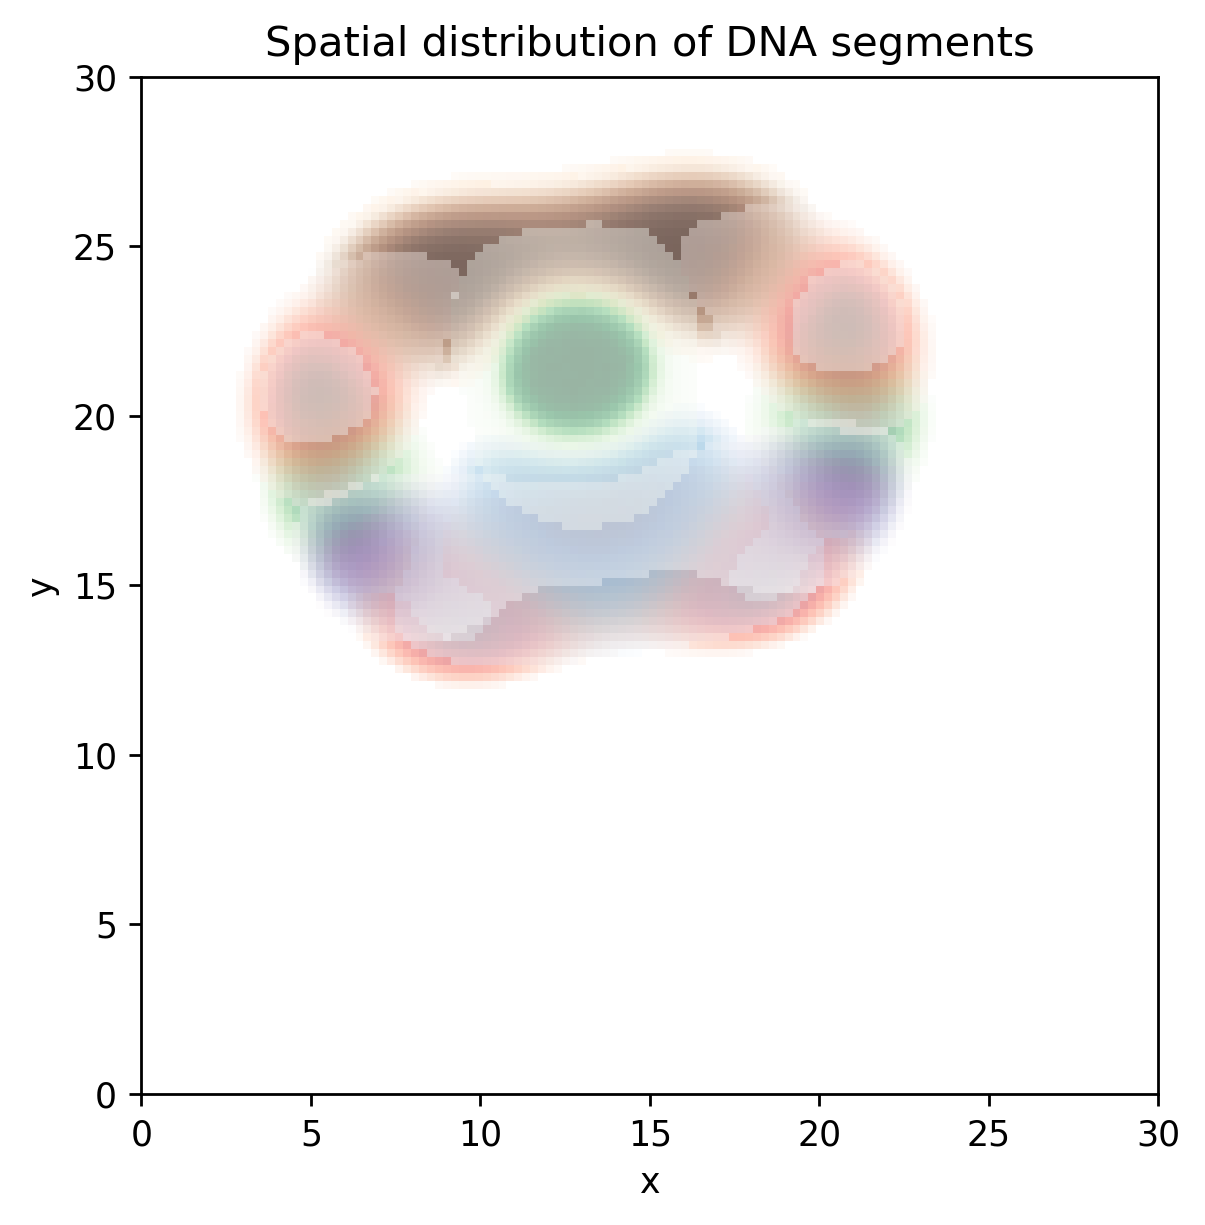

PP = 950,  PS = 1000


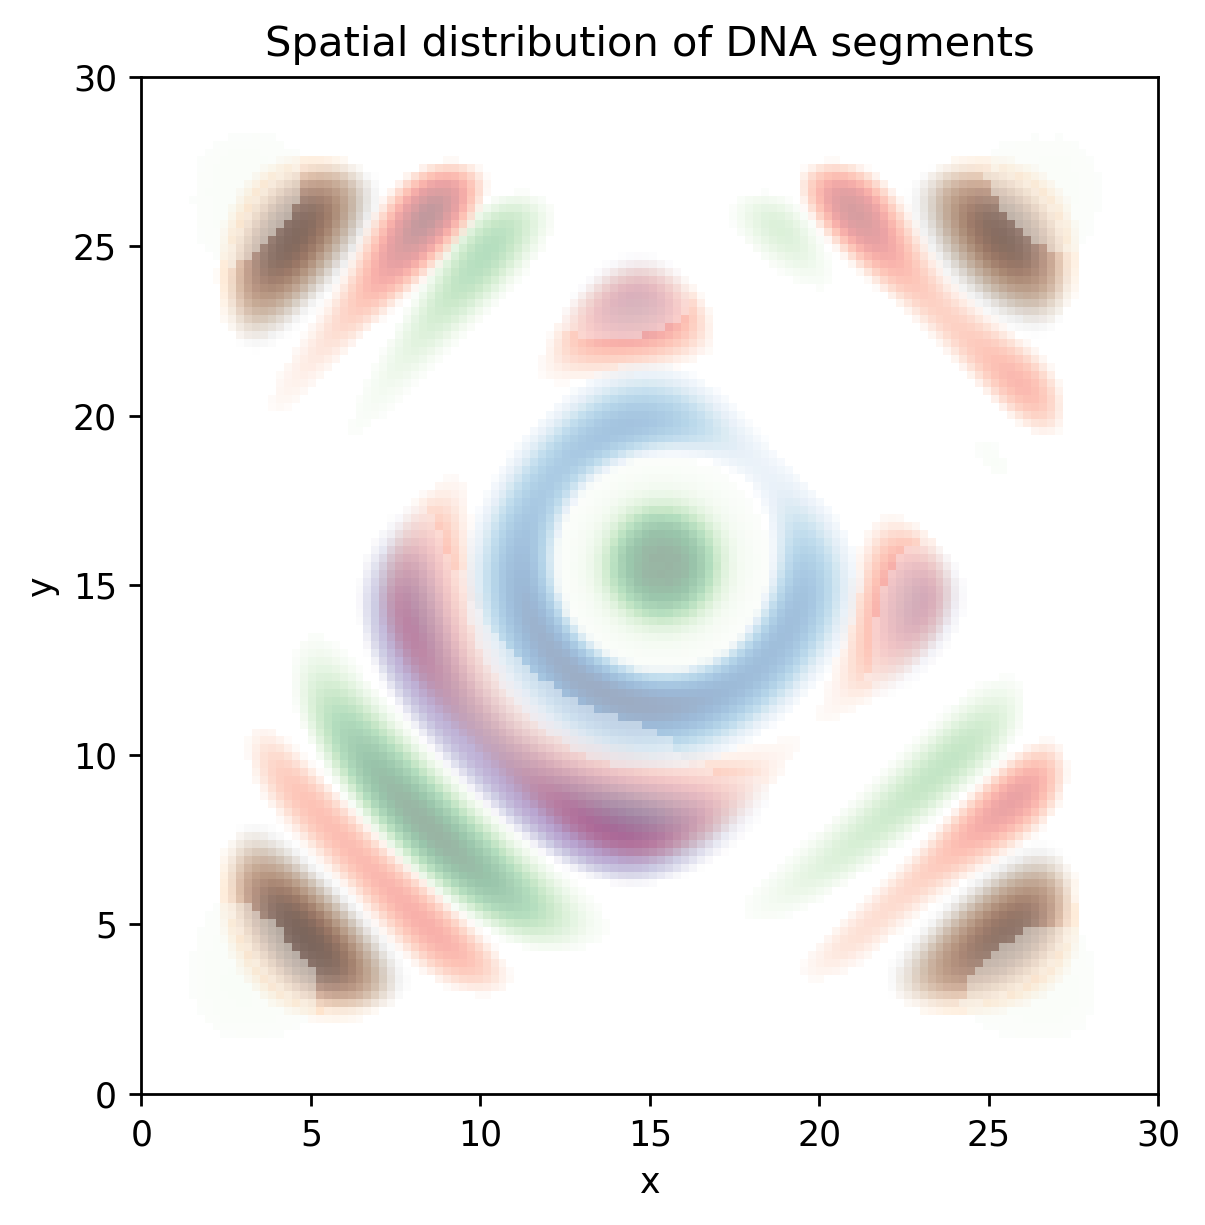

PP = 1000,  PS = 800


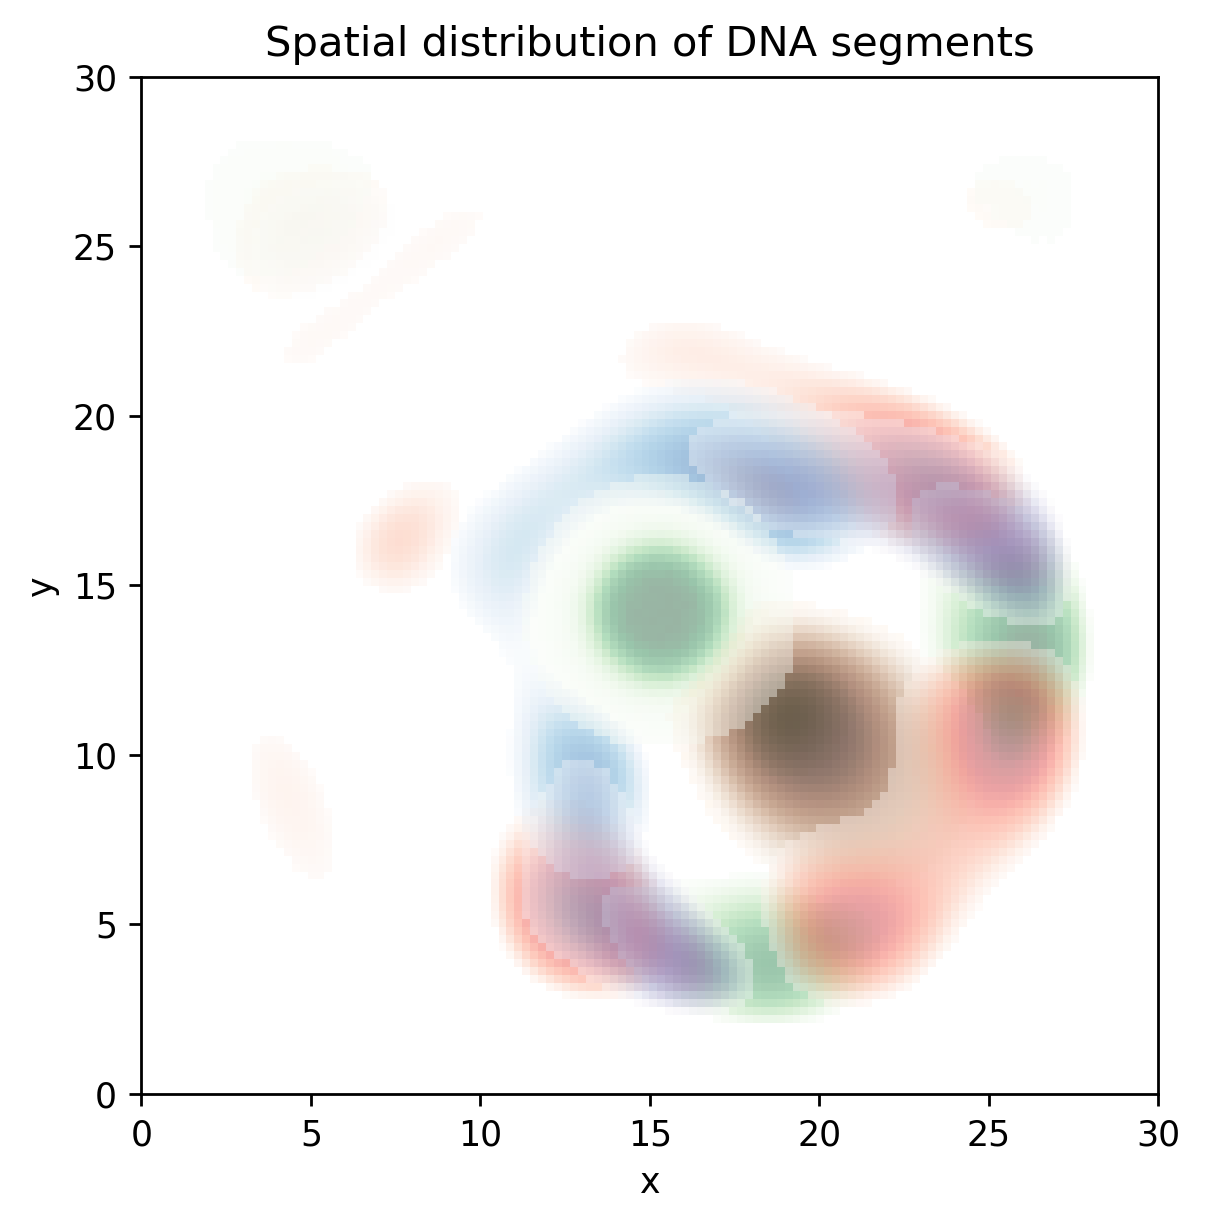

PP = 1000,  PS = 850


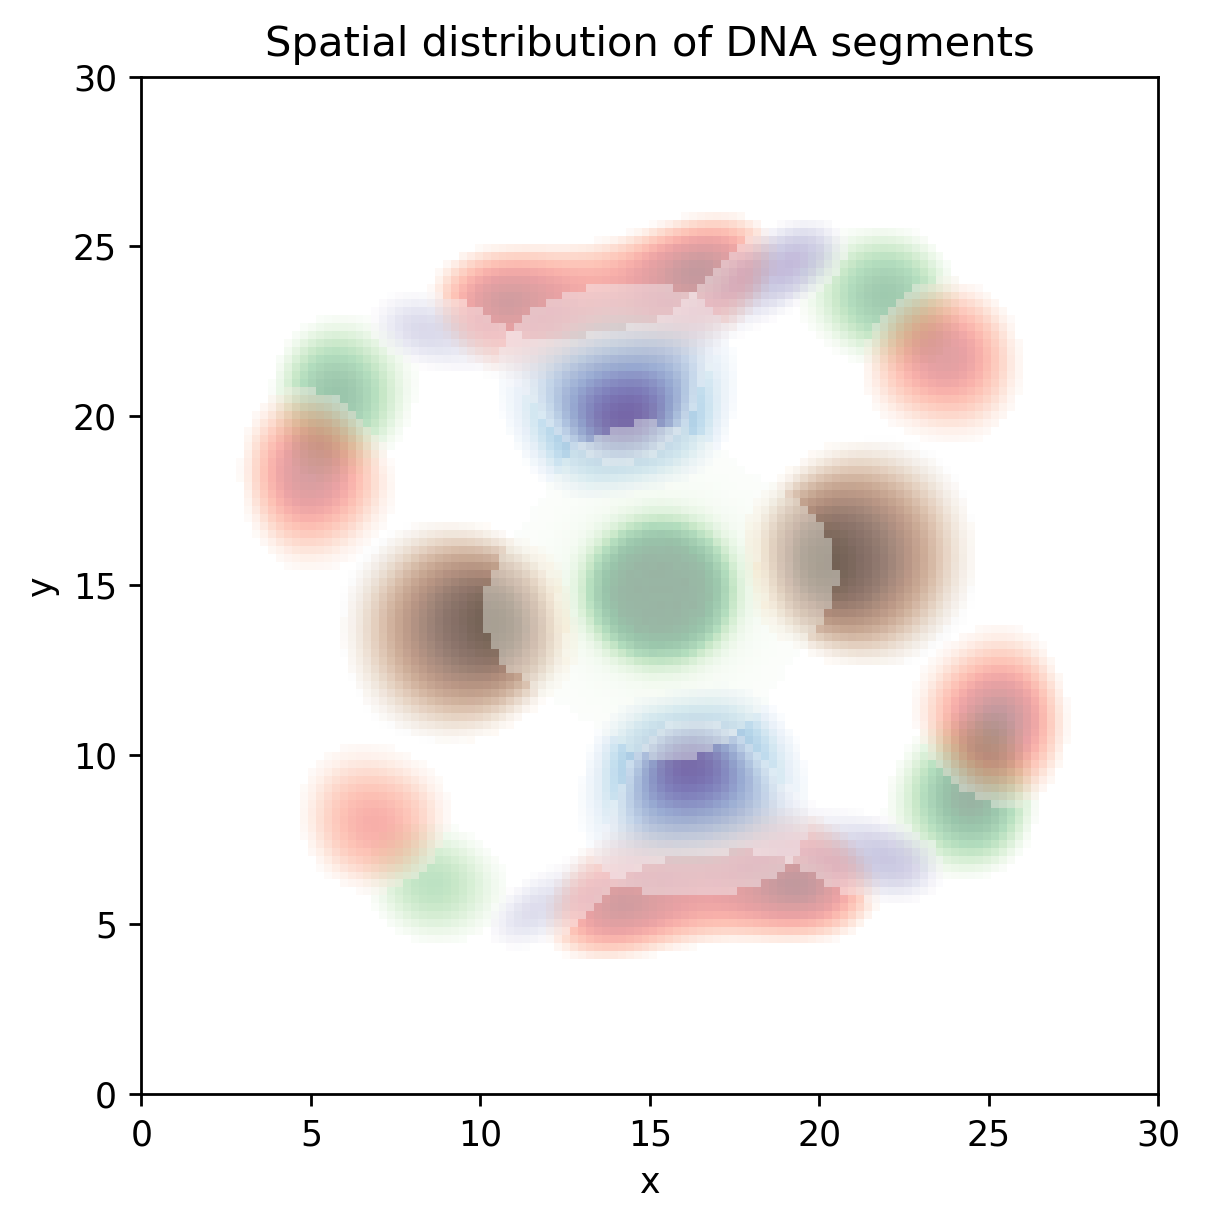

PP = 1000,  PS = 900


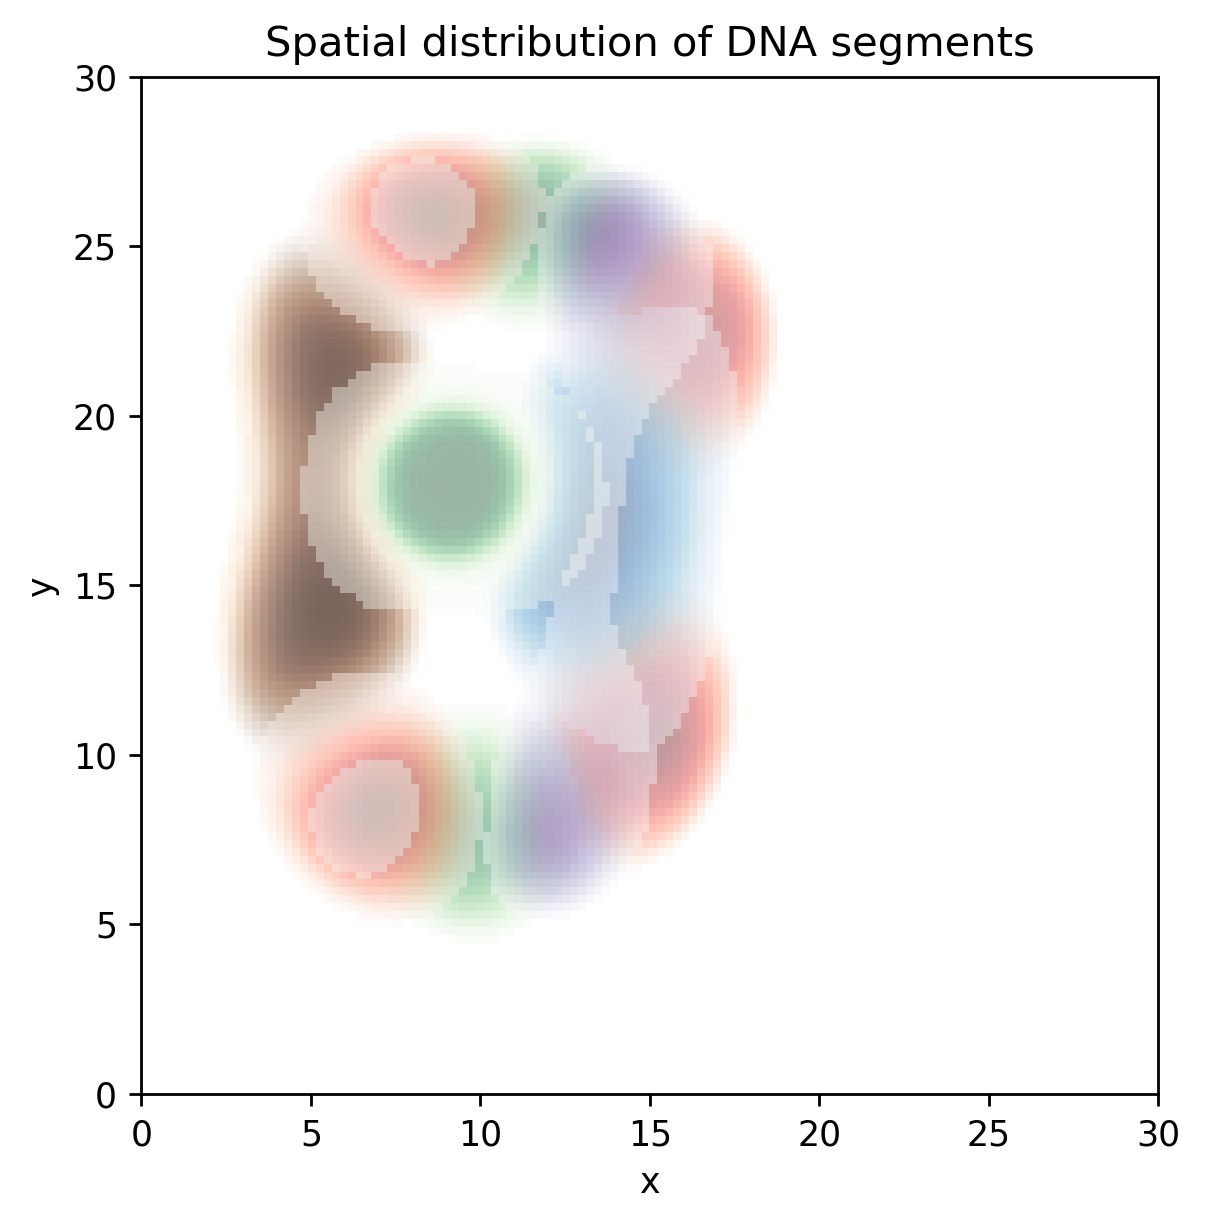

PP = 1000,  PS = 950


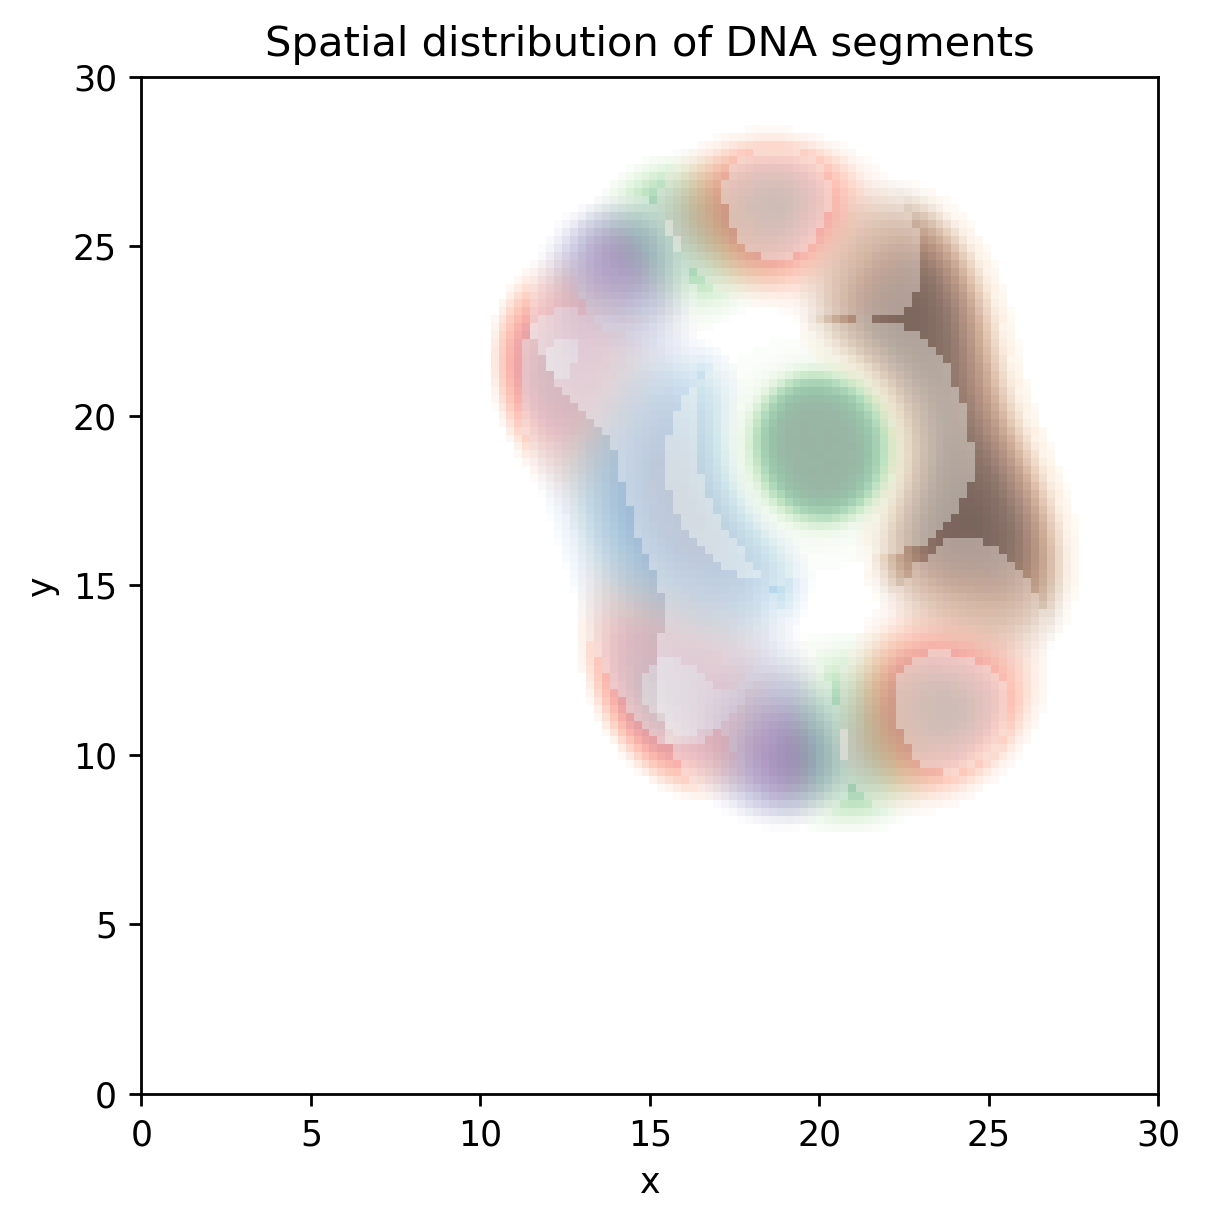

PP = 1000,  PS = 1000


In [11]:
plot_sweep_2d(phi_blocks_grid, Ns, phibars)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

L = 30
def diff_sweep_2d(phi_blocks_grid, Ns, phibars, Lx=L, Ly=L,
                  percentile=85, shift_x=0, shift_y=0, dpi=200):
    """
    phi_blocks_grid: object array with shape (len(Ns), len(phibars))
                     where [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    Ns = list(Ns)
    phibars = list(phibars)

    #if save_dir:
        #Path(save_dir).mkdir(parents=True, exist_ok=True)

    M, K = phi_blocks_grid.shape
    for i in range(M):
        for j in range(K):
            plt.close('all')

            # Draw (this likely creates a new fig internally)
            #plt.plot(diff_grid[i, j])
            print(f"PP = {int(Ns[i])},  PS = {phibars[j]:g}")
            phi = np.sum(phi_blocks_grid[i,j][1:, :, :], axis=0)
            plt.imshow(phi, cmap='viridis', interpolation='nearest', aspect=1)



            plt.show()



PP = 800,  PS = 800


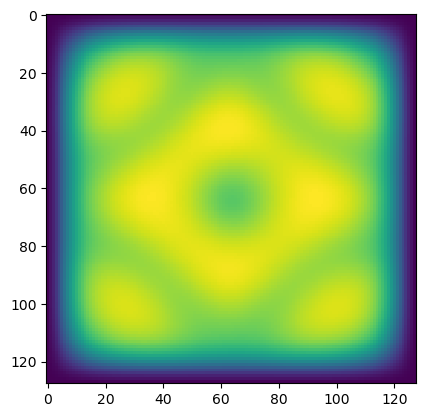

PP = 800,  PS = 850


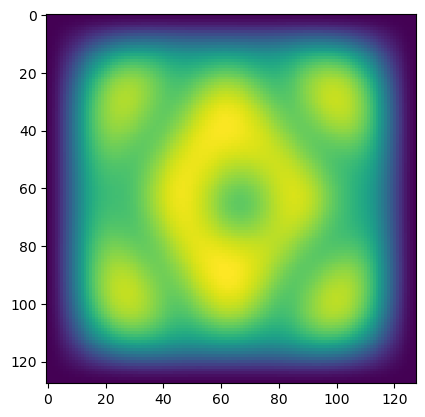

PP = 800,  PS = 900


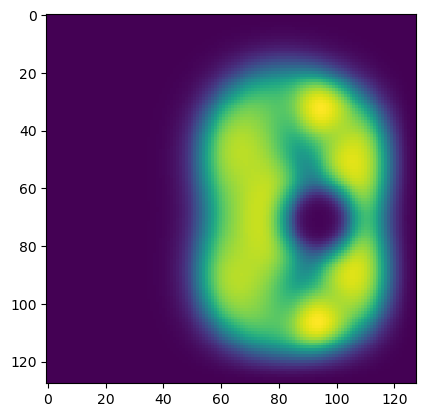

PP = 800,  PS = 950


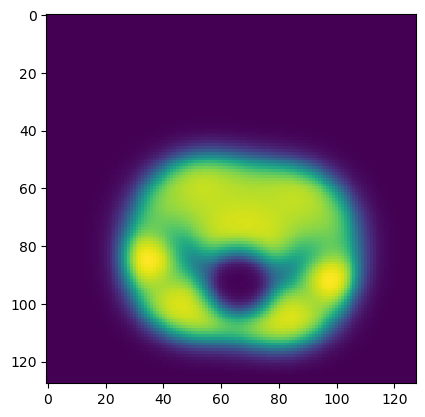

PP = 800,  PS = 1000


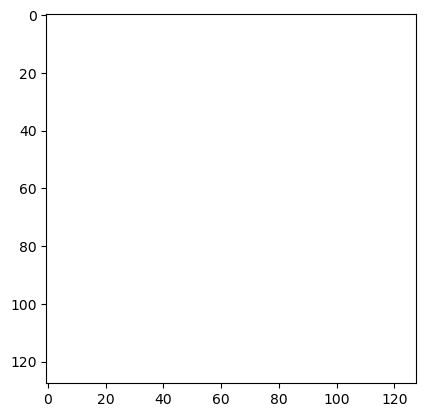

PP = 850,  PS = 800


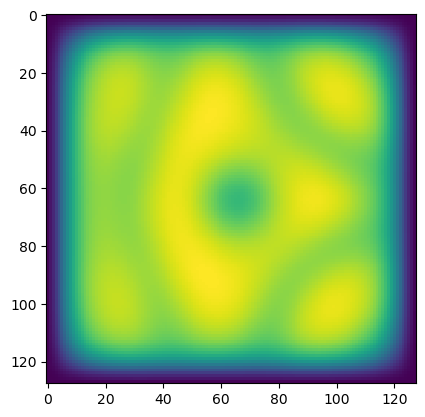

PP = 850,  PS = 850


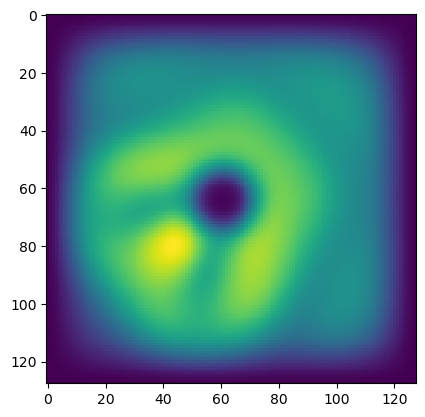

PP = 850,  PS = 900


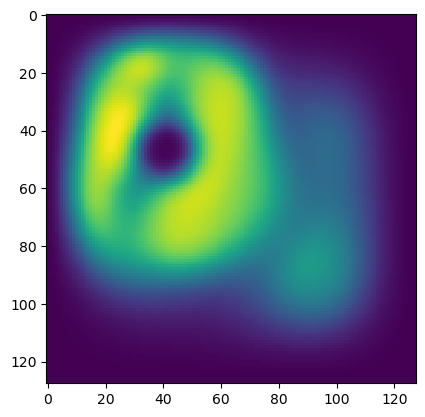

PP = 850,  PS = 950


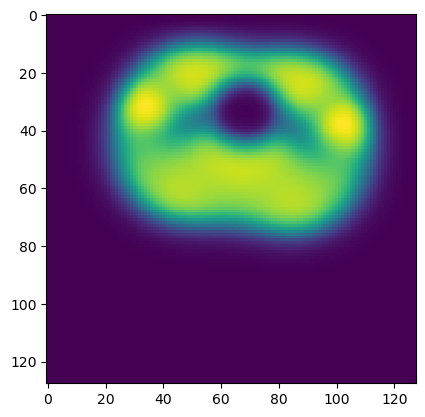

PP = 850,  PS = 1000


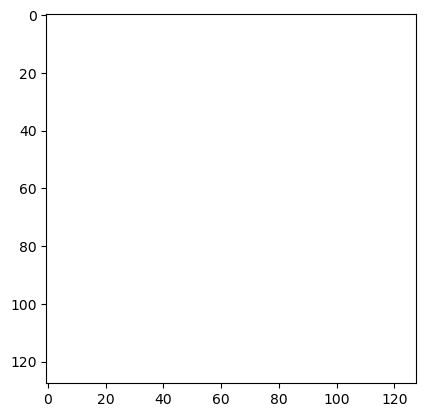

PP = 900,  PS = 800


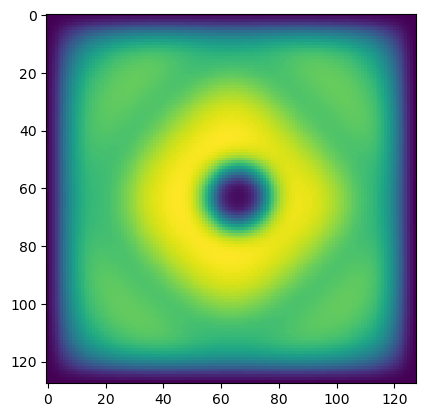

PP = 900,  PS = 850


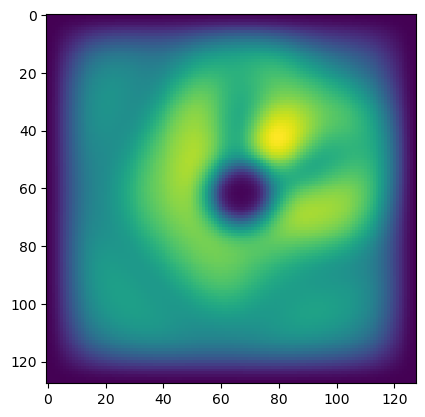

PP = 900,  PS = 900


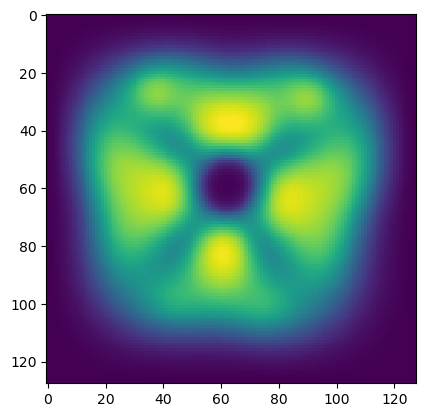

PP = 900,  PS = 950


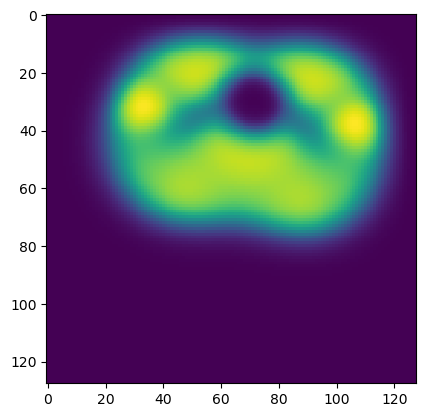

PP = 900,  PS = 1000


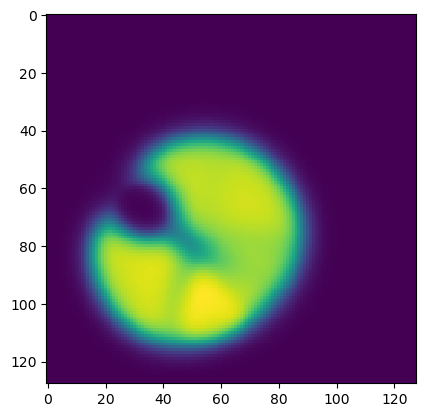

PP = 950,  PS = 800


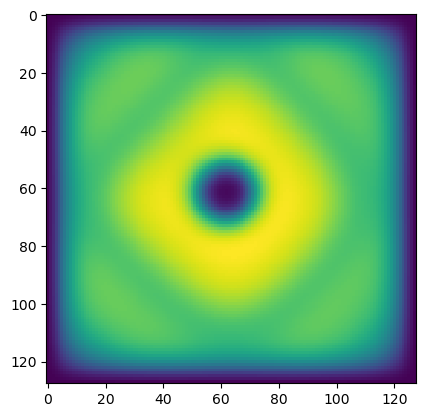

PP = 950,  PS = 850


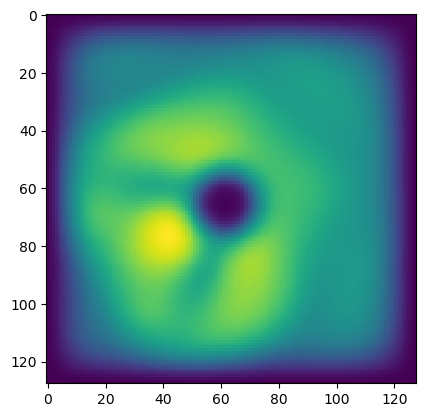

PP = 950,  PS = 900


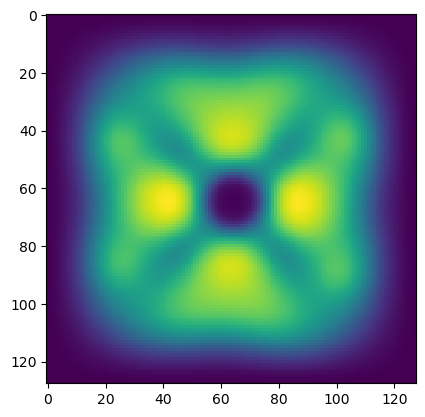

PP = 950,  PS = 950


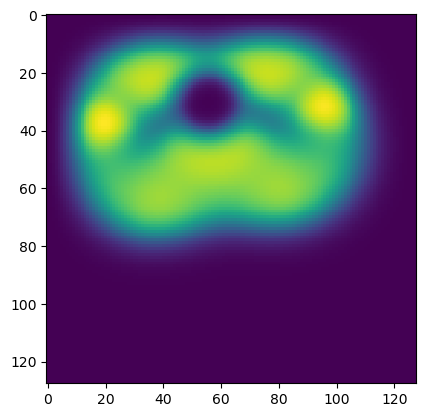

PP = 950,  PS = 1000


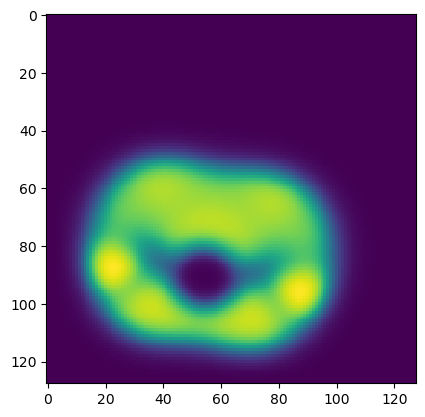

PP = 1000,  PS = 800


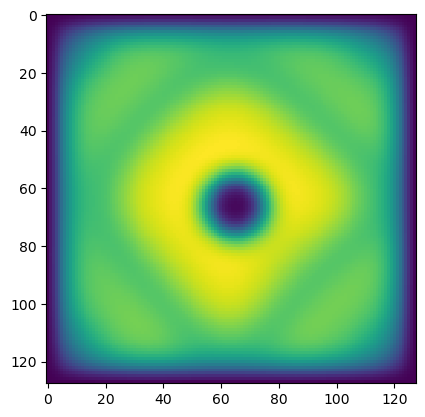

PP = 1000,  PS = 850


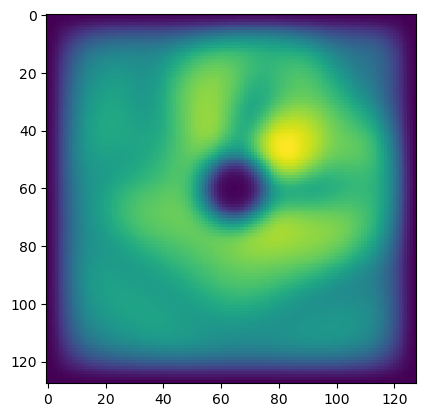

PP = 1000,  PS = 900


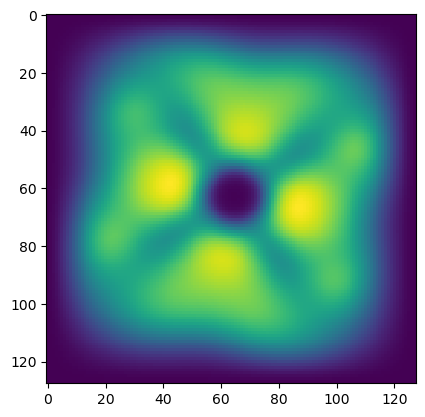

PP = 1000,  PS = 950


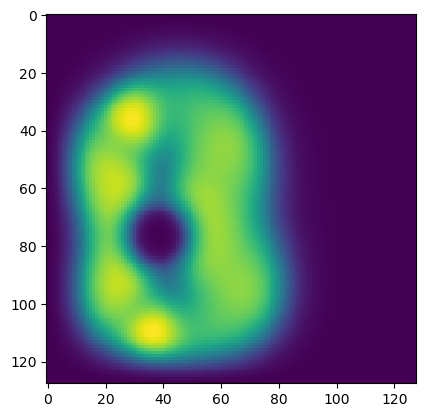

PP = 1000,  PS = 1000


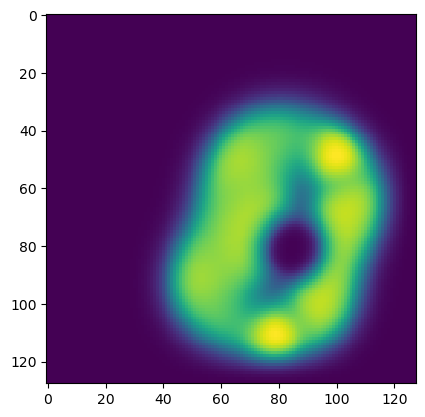

In [21]:
diff_sweep_2d(phi_blocks_grid, Ns, phibars)

In [6]:
L = 56
def free_energy_sweep_2d(phi_blocks_grid, Ns, phibars, Lx=L, Ly=L,
                  percentile=85, shift_x=0, shift_y=0, dpi=200):
    """
    phi_blocks_grid: object array with shape (len(Ns), len(phibars))
                     where [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    Ns = list(Ns)
    phibars = list(phibars)

    #if save_dir:
        #Path(save_dir).mkdir(parents=True, exist_ok=True)

    M, K = phi_blocks_grid.shape
    for i in range(M):
        for j in range(K):
            plt.close('all')

            free_energy_hist = np.array(free_energy_grid[i,j])
            plt.plot(free_energy_hist[:, 0],label="Free energy")
            plt.plot(free_energy_hist[:, 1],label="Interaction energy")
            plt.plot(free_energy_hist[:, 2],label="Entropy+Constrain")
            #plt.yscale('log')
            plt.title("Free energy vs iterations")
            plt.ylabel("Free energy")
            plt.xlabel("Iteration")
            plt.legend()
            plt.grid()

            print(f"PP = {int(Ns[i])},  PS = {phibars[j]:g}")

            plt.show()



PP = 800,  PS = 800


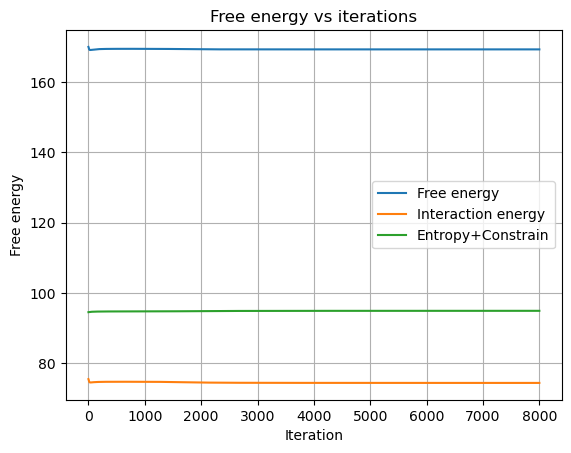

PP = 800,  PS = 850


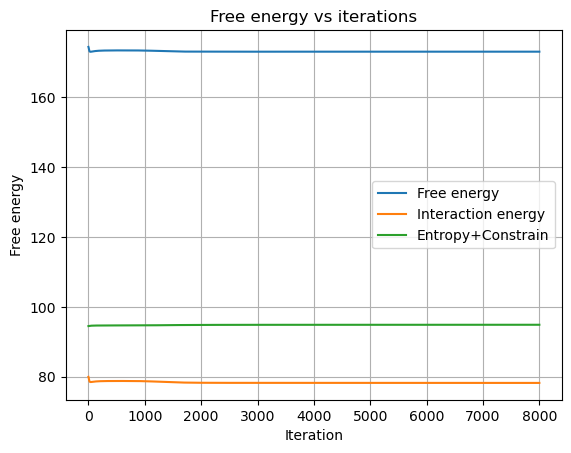

PP = 800,  PS = 900


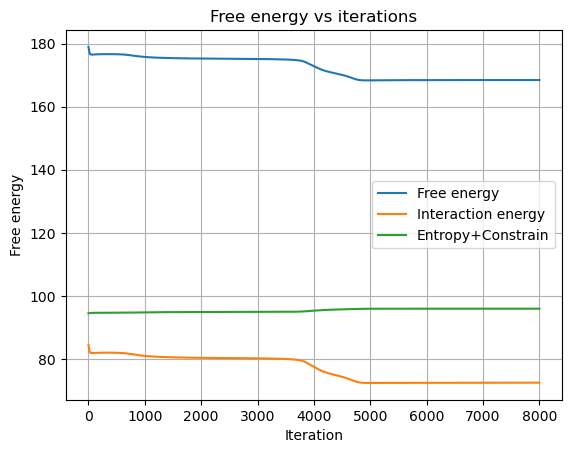

PP = 800,  PS = 950


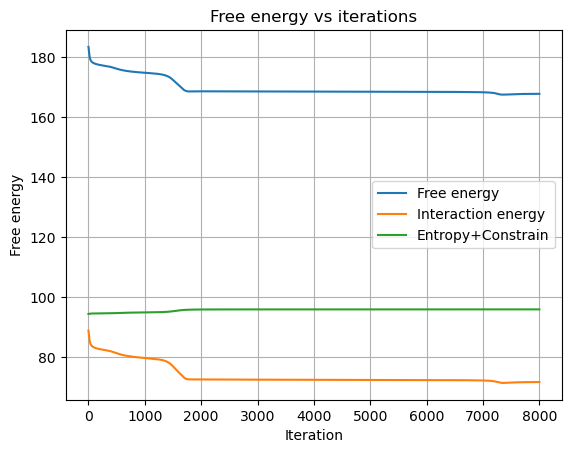

PP = 800,  PS = 1000


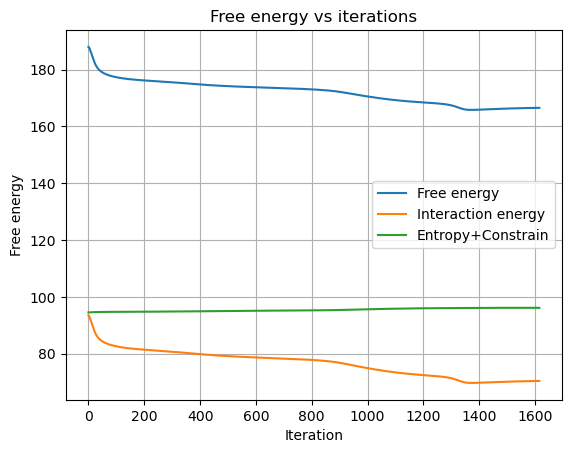

PP = 850,  PS = 800


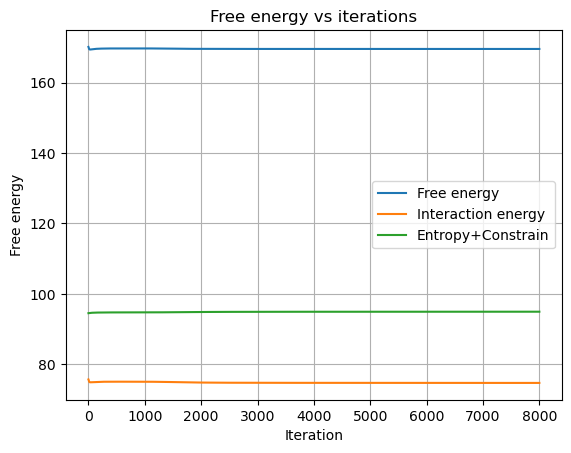

PP = 850,  PS = 850


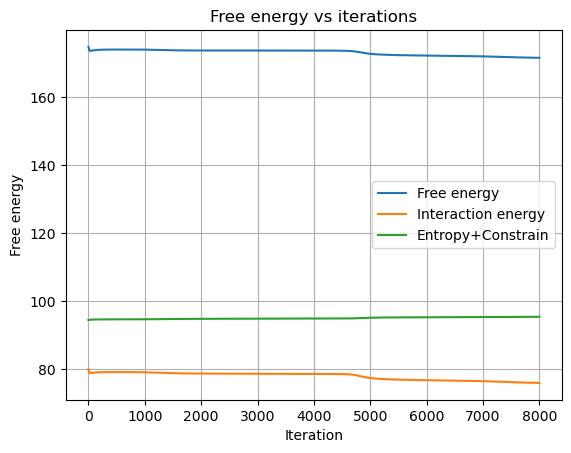

PP = 850,  PS = 900


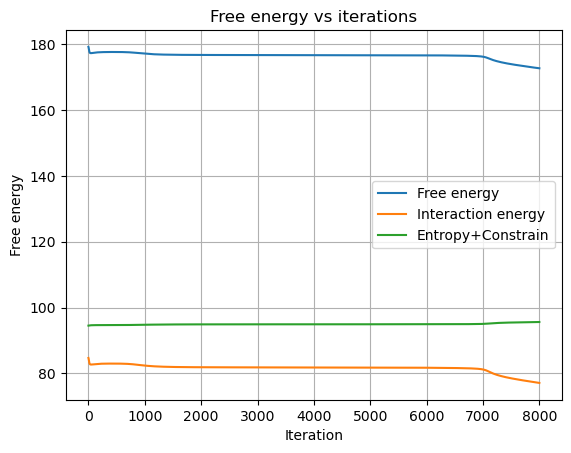

PP = 850,  PS = 950


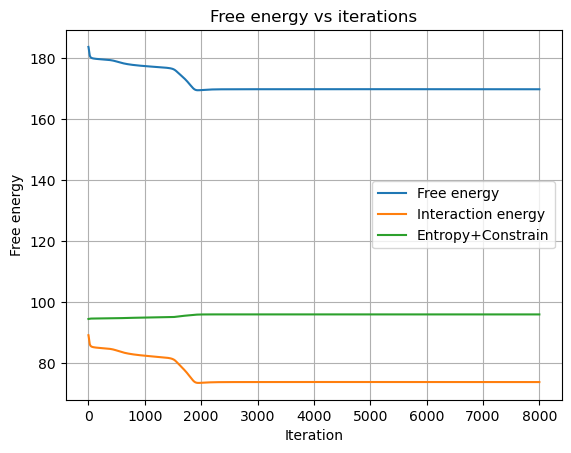

PP = 850,  PS = 1000


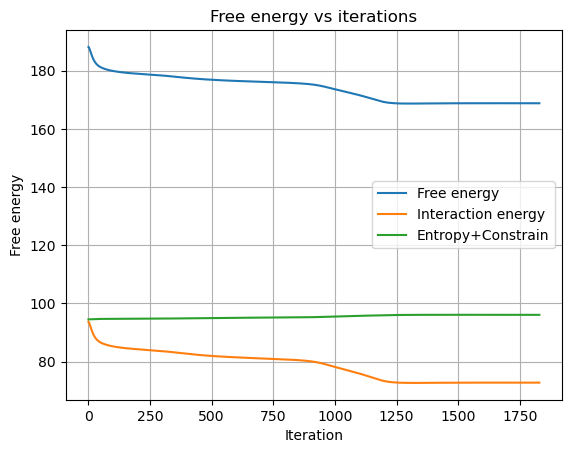

PP = 900,  PS = 800


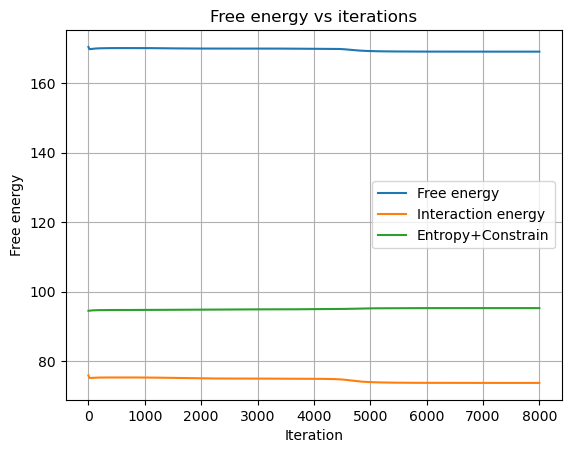

PP = 900,  PS = 850


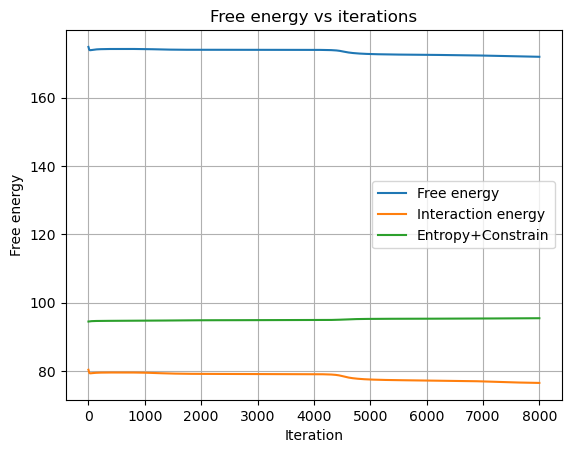

PP = 900,  PS = 900


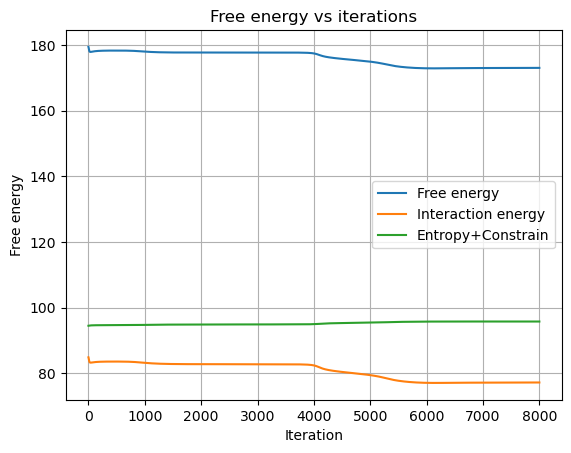

PP = 900,  PS = 950


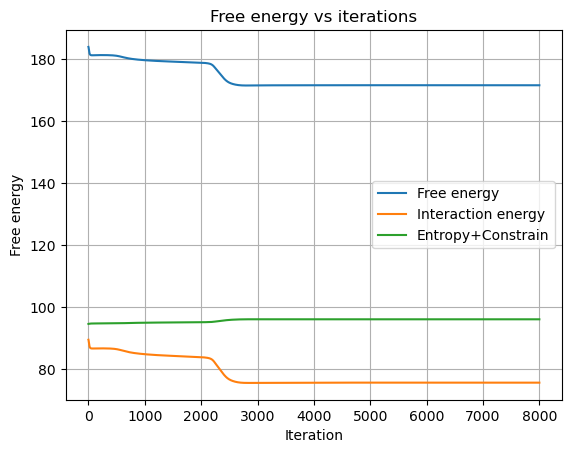

PP = 900,  PS = 1000


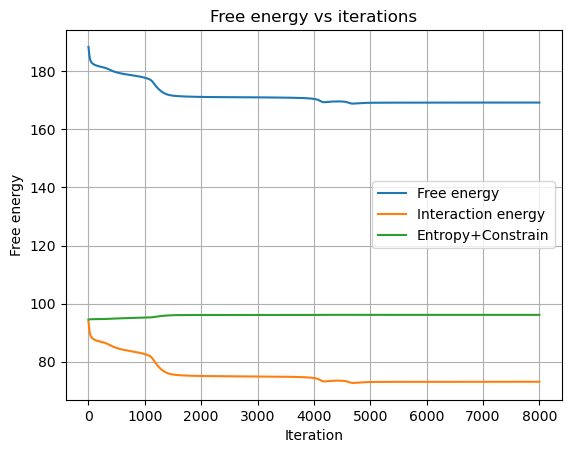

PP = 950,  PS = 800


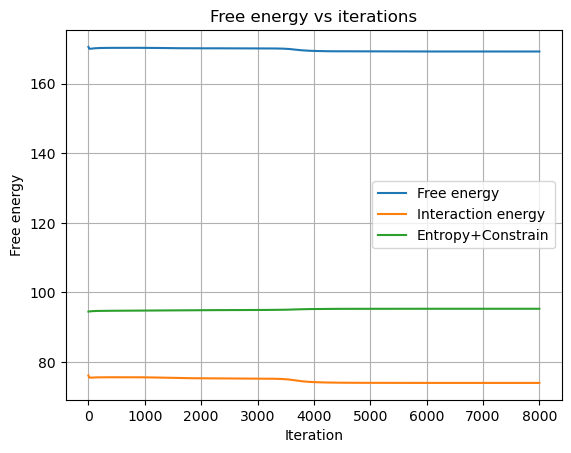

PP = 950,  PS = 850


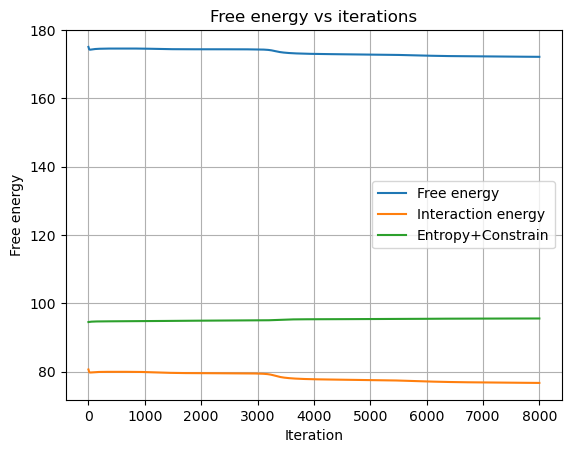

PP = 950,  PS = 900


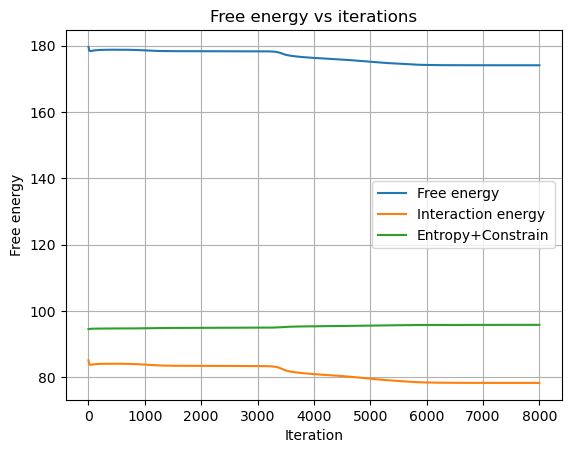

PP = 950,  PS = 950


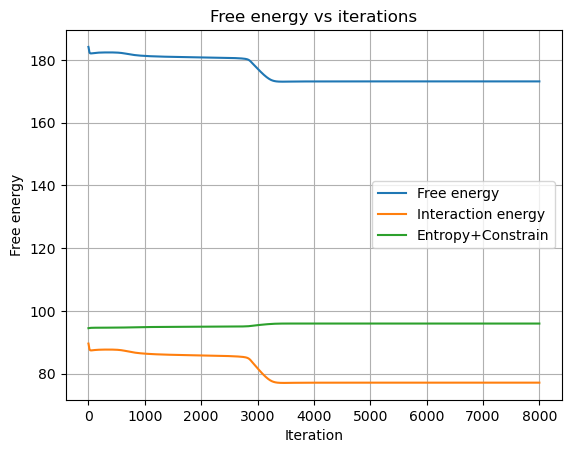

PP = 950,  PS = 1000


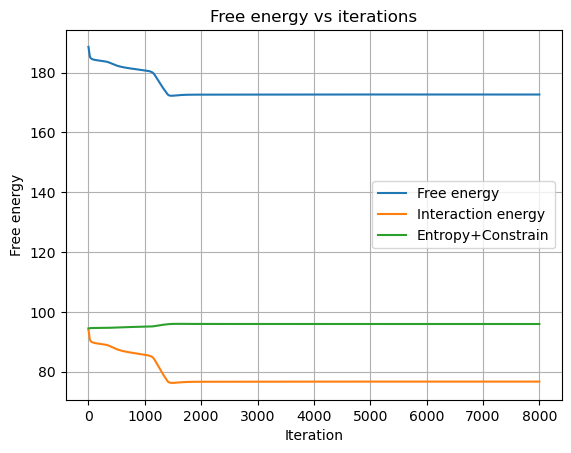

PP = 1000,  PS = 800


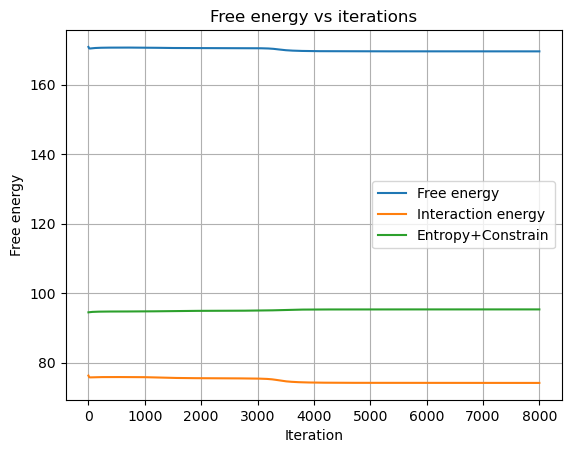

PP = 1000,  PS = 850


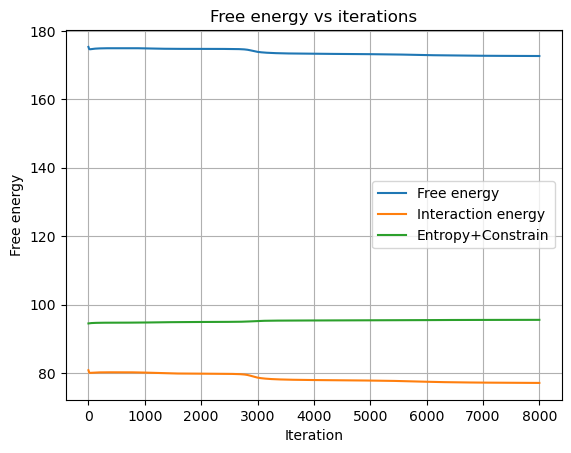

PP = 1000,  PS = 900


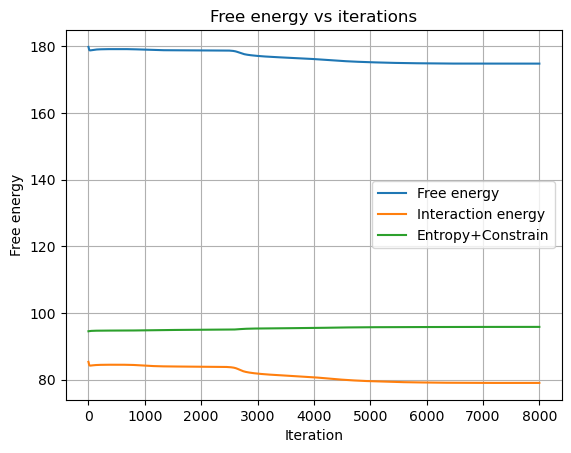

PP = 1000,  PS = 950


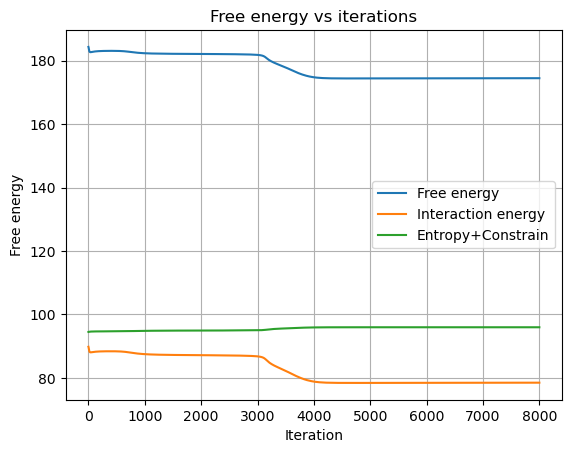

PP = 1000,  PS = 1000


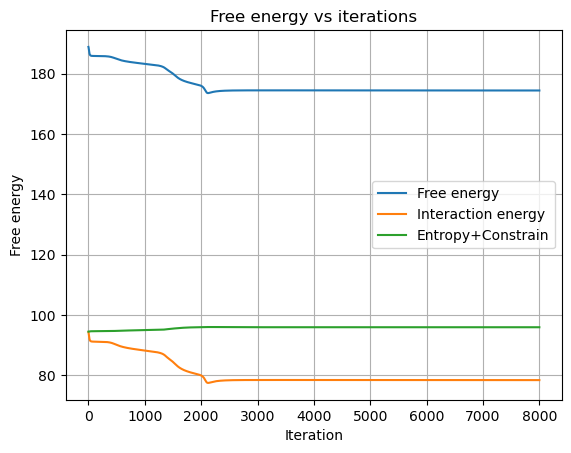

In [7]:
free_energy_sweep_2d(phi_blocks_grid, Ns, phibars)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

L = 30
def corr_sweep_2d(phi_blocks_grid, Ns, phibars, Lx=L, Ly=L,
                  percentile=85, shift_x=0, shift_y=0, dpi=200):
    """
    phi_blocks_grid: object array with shape (len(Ns), len(phibars))
                     where [i, j] corresponds to N=Ns[i], phibar=phibars[j]
    """
    Ns = list(Ns)
    phibars = list(phibars)

    #if save_dir:
        #Path(save_dir).mkdir(parents=True, exist_ok=True)

    M, K = phi_blocks_grid.shape
    for i in range(M):
        for j in range(K):
            plt.close('all')

            # Draw (this likely creates a new fig internally)
            #plt.plot(diff_grid[i, j])
            print(f"PP = {int(Ns[i])},  PS = {phibars[j]:g}")
            dynamic_range = 1 * np.std(corr_2d_grid[i, j])
            plt.imshow(corr_2d_grid[i, j], cmap='viridis', interpolation='nearest', aspect=1,
                       #vmin=-dynamic_range,
                       vmax=+dynamic_range
                       )
            plt.show()



PP = 800,  PS = 800


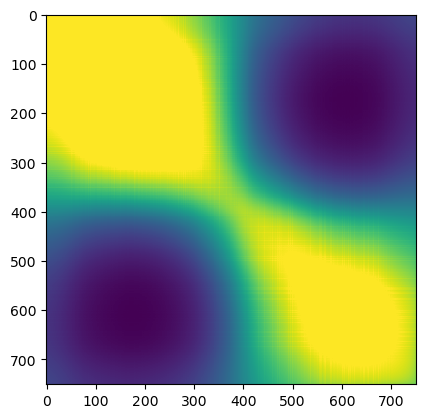

PP = 800,  PS = 850


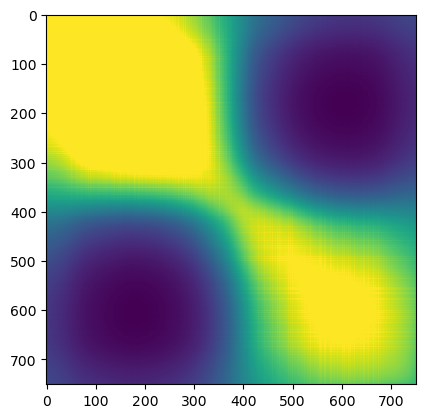

PP = 800,  PS = 900


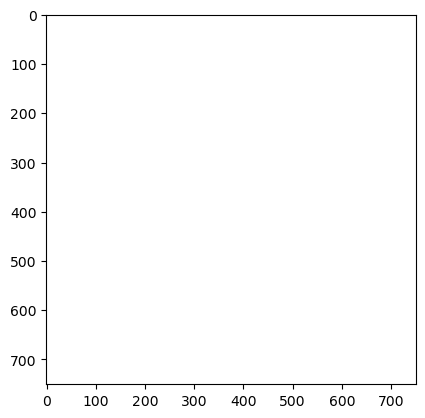

PP = 800,  PS = 950


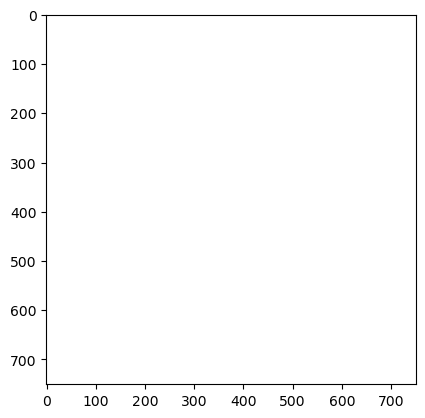

PP = 800,  PS = 1000


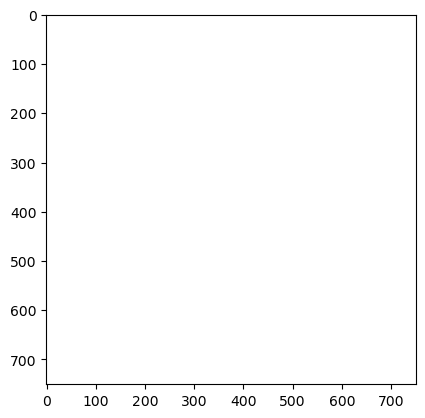

PP = 850,  PS = 800


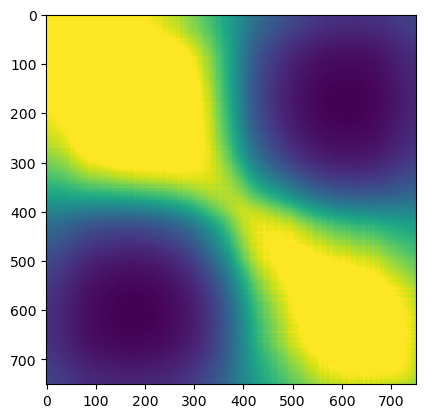

PP = 850,  PS = 850


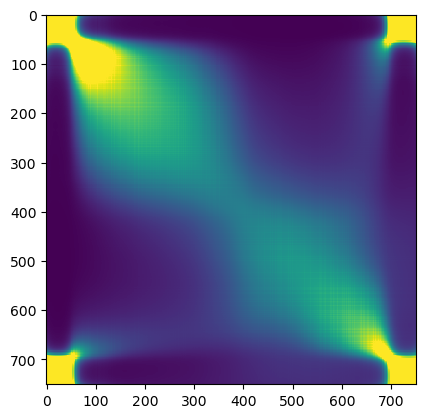

PP = 850,  PS = 900


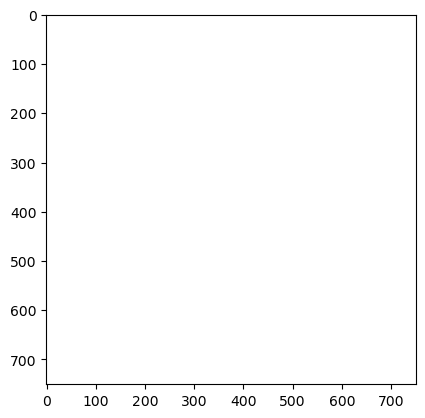

PP = 850,  PS = 950


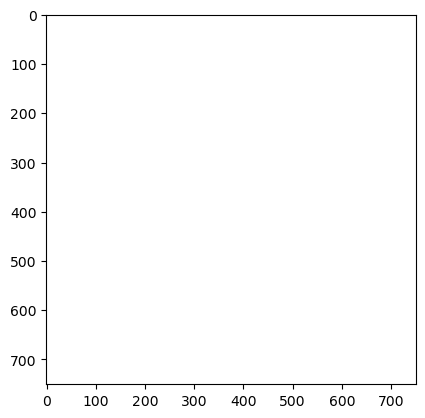

PP = 850,  PS = 1000


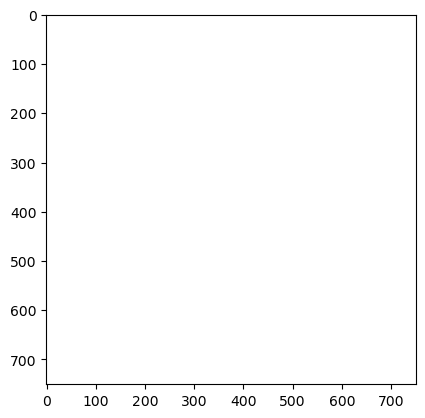

PP = 900,  PS = 800


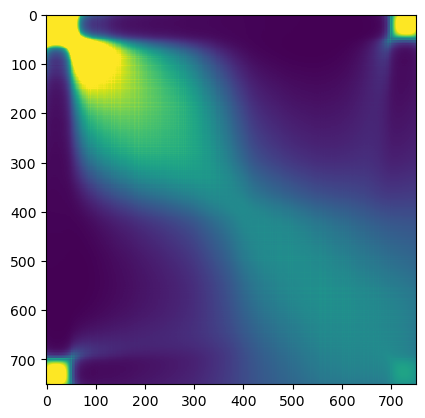

PP = 900,  PS = 850


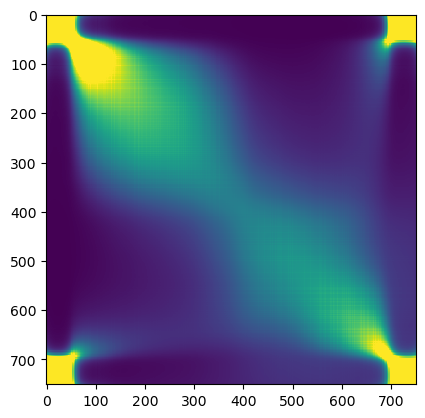

PP = 900,  PS = 900


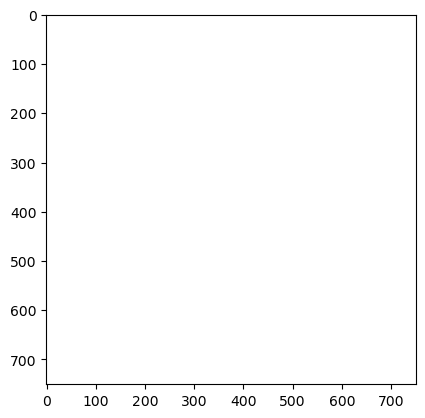

PP = 900,  PS = 950


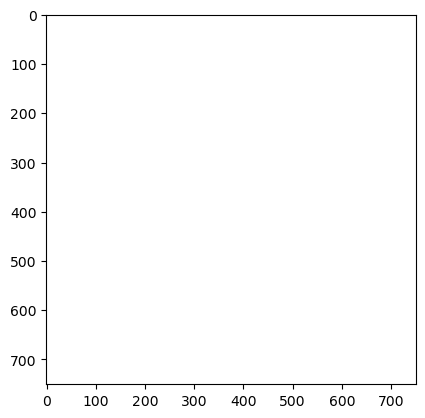

PP = 900,  PS = 1000


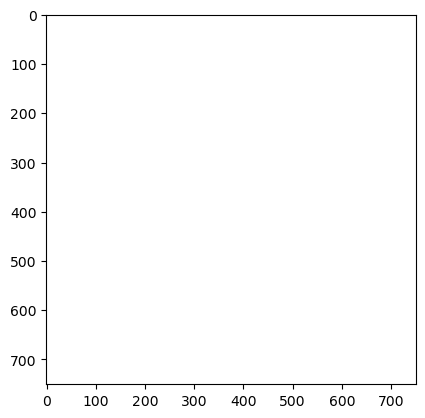

PP = 950,  PS = 800


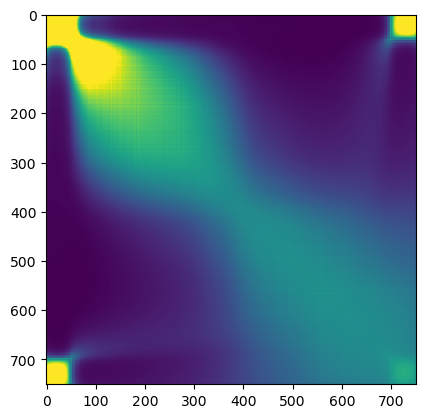

PP = 950,  PS = 850


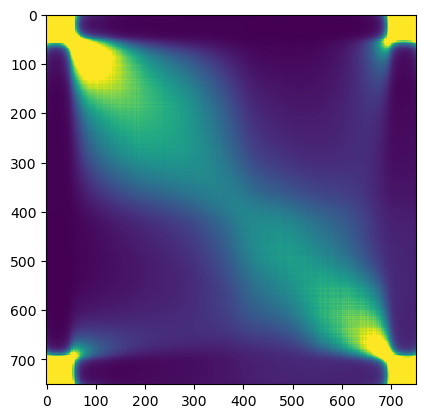

PP = 950,  PS = 900


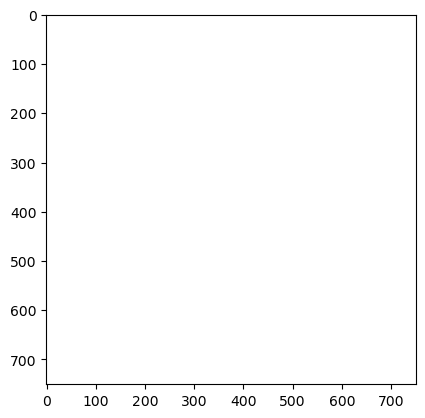

PP = 950,  PS = 950


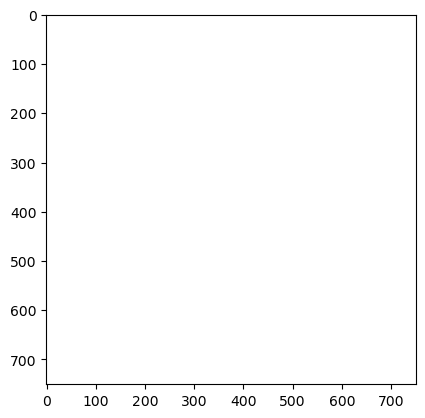

PP = 950,  PS = 1000


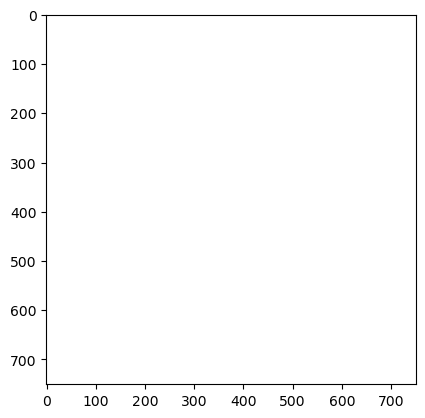

PP = 1000,  PS = 800


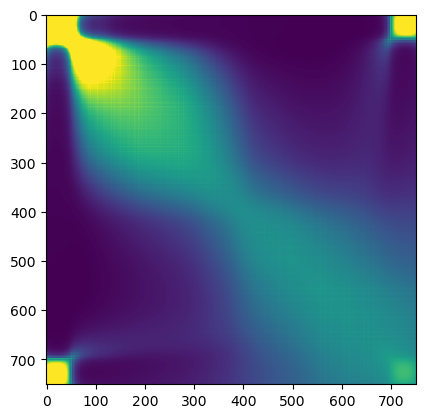

PP = 1000,  PS = 850


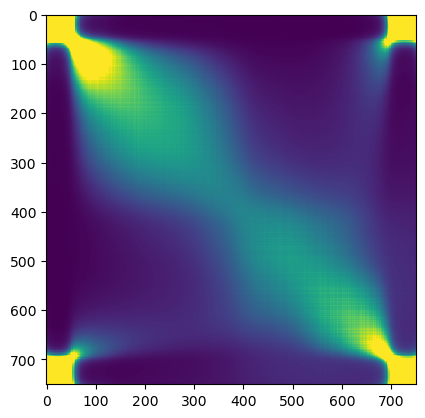

PP = 1000,  PS = 900


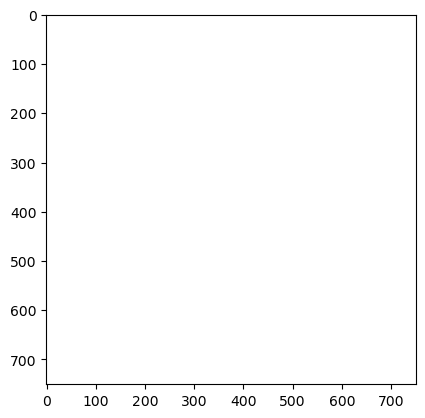

PP = 1000,  PS = 950


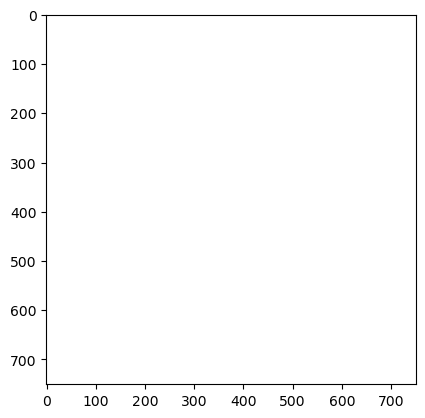

PP = 1000,  PS = 1000


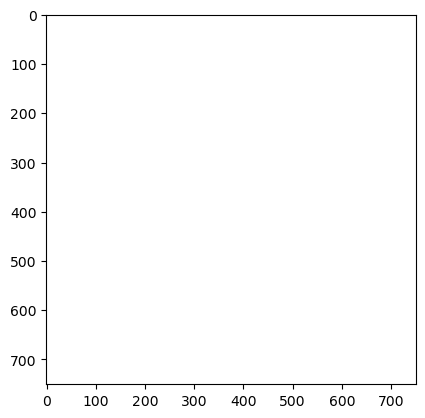

In [24]:
corr_sweep_2d(phi_blocks_grid, Ns, phibars)